# 11장 — 그래프 표현 학습과 그래프 신경망

| | |
| --- | --- |
| **책** | Alessandro Negro 외, *Knowledge Graphs and LLMs in Action* (Manning) **11장** |
| **해설 원본** | [11_..._ko_explained.md 열기](../../11_graph_representation_learning_and_graph_neural_networks_ko_explained.md) |
| **원서 원문** | [11_....md 열기](../../11_graph_representation_learning_and_graph_neural_networks.md) |
| **이 폴더** | [tasks.py](./tasks.py) · [listings/](./listings) · [requirements.lock](./requirements.lock) |
| **원서 저장소** | [alenegro81/.../chapters/ch13 열기](https://github.com/alenegro81/knowledge-graphs-and-llms-in-action/tree/main/chapters/ch13) |
| **리스팅 번호** | **오프셋으로 표현할 수 없다.** 번호가 붙은 파일은 `13.1 Applying node2vec ....py` **하나뿐** 이고, 책 11.2\~11.7 은 번호 없는 `GNN_all_in_one.py` 안의 개별 클래스다. 그래서 `study.toml` 이 번호 대신 `path` + `symbol` 로 선언한다 (아래 헬퍼 셀이 출력하는 대조표 참고) |
| **외부 서비스** | **없다.** 이 장은 Neo4j 를 쓰지 않는다 |

---

9장과 10장은 **사람이 손으로 설계한 특징** 으로 그래프 위에서 머신러닝을 했다. 해석은 투명했지만, 노드가 수백만 개인 지식 그래프로 규모를 키우면 특징 하나를 고안하는 비용이 감당되지 않는다. 11장은 그 특징을 **자동으로 학습** 하는 쪽으로 방향을 튼다. 즉 그래프 구조와 노드 속성으로부터 밀집 벡터(임베딩)를 직접 배우는 **그래프 표현 학습(GRL)** 이다.

이 장이 앞 장들과 결정적으로 다른 점은 **데이터베이스가 아니라 모델이 주인공** 이라는 것이다. 3\~8장은 Neo4j 에 무엇을 어떻게 넣을지를 다뤘고, 9\~10장은 그 그래프에서 무엇을 뽑아낼지를 다뤘다. 11장은 뽑아낼 것을 사람이 정하지 않고 신경망이 정하게 만드는 방법을 다룬다. 그래서 이 노트북에는 Cypher 가 한 줄도 없고 대신 PyTorch 텐서가 있다.

절 순서에도 이유가 있다. **역사 → 통합 틀 → 가장 단순한 구현 → 그 한계 → 한계를 넘는 구조 → 그 구조의 일반화 → 다른 패러다임과의 결합** 이라는 한 줄기다.

| 절 | 내용 | 이 절이 답하는 질문 | 리스팅 |
| --- | --- | --- | --- |
| 11.1 | 그래프 표현 학습에서의 임베딩 — 세대별 진화의 이야기 | 임베딩이란 무엇이고 어떤 축으로 나뉘나 | — |
| 11.2 | 인코더–디코더 모델 — 그래프 임베딩을 하나로 묶는 틀 | 서로 달라 보이는 방법들을 어떤 렌즈로 함께 볼까 | 11.1 |
| 11.3 | 얕은 임베딩 — 그래프 표현으로 가는 첫 접근 | 가장 단순한 인코더는 무엇이고 왜 부족한가 | — |
| 11.4 | 지식 그래프에서의 임베딩 | 관계가 여러 종류일 때 손실과 디코더를 어떻게 짜나 | — |
| 11.5 | 메시지 전달과 그래프 신경망 | 얕은 임베딩의 한계를 어떤 구조가 넘어서나 | — |
| 11.6 | 일반화된 집계와 갱신 방법 | 집계·갱신을 어떻게 더 정교하게 만드나 | 11.2\~11.7 |
| 11.7 | GNN과 LLM의 시너지 | 구조 모델과 언어 모델을 어떻게 붙이나 | — |
| — | 실습 11-A · 11-B · 11-C · 요약 | | |

> **한 문장 요약** — 그래프를 벡터로 바꾸는 일을 **인코더–디코더** 하나의 틀로 통일해 보면 룩업 테이블에 불과한 **얕은 임베딩**(node2vec)의 네 가지 한계가 드러나고, 그 한계를 **메시지 전달**(이웃 정보를 반복 집계·갱신)로 넘어선 것이 **GNN** 이며, 집계·갱신 자리에 정규화·어텐션·게이트·점핑 놀리지를 끼워 넣으면 오늘날의 GNN 아키텍처들이 된다.

이 장은 **이론 비중이 크다.** 리스팅은 일곱 개지만 그중 여섯은 10\~90줄짜리 `nn.Module` 조각이고, 장의 무게는 수식과 개념 구분에 실려 있다. 그래서 이 노트북은 수식을 LaTeX 로 옮기고 기호마다 뜻을 밝히는 데 지면을 많이 썼다. 코드는 그 개념이 실제로 어떤 텐서 연산으로 내려오는지 확인하는 용도다.


---
## 실행 환경 — 11장은 Neo4j 가 필요 없다

3\~10장과 다르다. 이 장에는 데이터베이스도, API 키도, 도커 컨테이너도 없다. 필요한 것은 **파이썬 패키지뿐** 이다. 가라테 클럽 네트워크(34개 노드)는 `networkx` 에 내장돼 있고, GNN 예제는 무작위 텐서로 순전파만 한다.

교재 루트의 `.venv`(Python 3.10) 커널에서 돌아간다. 처음이면 교재 루트에서 [`setup_env.py`](../../../setup_env.py) 를 한 번 실행한다.

```bash
python3 setup_env.py
```

그다음 **이 챕터 폴더에서** 챕터별 의존성을 설치한다. 챕터마다 `requirements.lock` 이 다른 버전을 pin 하므로, 다른 챕터를 돌리다 왔다면 이 장의 `init` 을 다시 돌린다.

```bash
cd "source/Alessandro Negro - Knowledge Graphs and LLMs in Action/chapter_11_graph_representation_learning_and_graph_neural_networks/src/ch13"
python tasks.py --list      # 태스크 목록
python tasks.py init        # requirements.lock 설치
```

### 필요한 패키지와 비용

| 패키지 | 쓰는 곳 | 비고 |
| --- | --- | --- |
| `torch` | 11.2\~11.7 의 모든 `nn.Module` | **설치가 가장 무겁다.** 휠이 수 GB, 네트워크에 따라 수 분 |
| `networkx` | `karate_club_graph()`, 그래프 그리기 | 가볍다 |
| `node2vec` | 책 11.1 의 랜덤 워크 + 임베딩 학습 | `gensim`(Word2Vec)을 함께 끌어온다 |
| `scikit-learn` | t-SNE 로 16차원 임베딩을 2차원에 투영 | |
| `matplotlib` | 그래프·임베딩 산점도 | |
| `numpy` | 임베딩 행렬 조립 | |

> **⚠️ `torch` 설치는 이 장에서 가장 오래 걸리는 단계다.** CPU 휠만 받아도 수백 MB, CUDA 휠이 걸리면 2\~3 GB 를 내려받는다. 네트워크가 느리면 `python tasks.py init` 하나에 몇 분이 걸릴 수 있으니 회의 중에 처음 돌리지 말고 미리 해 둔다.
>
> **GPU 는 없어도 된다.** 이 장의 예제는 노드 34개 그래프와 `[2, 10, 5, 64]` 크기 무작위 텐서가 전부라 CPU 로 즉시 끝난다. GPU 가 있으면 빠르지만 체감 차이가 나지 않는다. 실제로 GPU 가 의미 있어지는 것은 **12장** 에서 진짜 데이터로 GNN 을 학습시킬 때다.

### 실행 시간 감각

| 셀 | 하는 일 | 실측 |
| --- | --- | --- |
| 환경 점검 | import 확인 | 1초 미만 |
| 책 11.1 node2vec | 34노드 × 20워크 × 길이 10 → Word2Vec 학습 + t-SNE + 그림 2장 | **1.2초** |
| 책 11.2\~11.7 순전파 | 무작위 텐서 1회 forward | 1초 미만 |
| 실습 11-A (p·q 격자) | node2vec 을 5회 반복 학습 | 수 초 |
| 실습 11-B · 11-C | 예외 재현 · 순전파 비교 | 1초 미만 |

**설치를 끝낸 뒤에는 오래 걸리는 셀이 하나도 없다.** 이 장에서 시간을 잡아먹는 것은 오직 `torch` 다운로드다. 그래서 건너뛰기 가드도 두지 않았다 — 모든 셀을 처음부터 끝까지 순서대로 실행하면 된다.


In [1]:
"""환경 점검 — 이 셀이 통과하면 이후 모든 셀을 돌릴 수 있다.

11장은 Neo4j 를 쓰지 않으므로 데이터베이스 연결 검사가 없다. 대신 이 장이 요구하는
파이썬 패키지가 현재 커널에서 임포트되는지만 본다. 하나라도 없으면 챕터 폴더에서
`python tasks.py init` 을 다시 돌려야 한다 — 챕터마다 requirements.lock 이 다르므로
다른 챕터를 돌리다 온 경우 이 장 것이 빠져 있을 수 있다.
"""
import importlib
import platform
from pathlib import Path

from studykit import config

STUDY = config.load()     # 위로 올라가며 study.toml 을 찾는다
HERE = Path.cwd()         # 주피터는 노트북 폴더를 cwd 로 둔다
REPO_DIR = "ch13"         # 업스트림 디렉터리명. 책 11장 = MEAP ch13

assert (HERE / "listings").is_dir(), f"cwd 가 챕터 폴더가 아니다: {HERE}"

print("교재      :", STUDY.title)
print("파이썬    :", platform.python_version(), "(study.toml 고정:", STUDY.python + ")")
print("작업 폴더 :", HERE.name)

# 이 장이 요구하는 것 — 전부 requirements.lock 에 있다.
REQUIRED = {
    "torch": "11.2~11.7 의 nn.Module 전부",
    "networkx": "karate_club_graph() 와 그래프 그리기",
    "node2vec": "책 11.1 의 랜덤 워크 + 임베딩 학습",
    "gensim": "node2vec 내부의 Word2Vec",
    "sklearn": "t-SNE 로 16차원 -> 2차원 투영",
    "matplotlib": "그래프·임베딩 산점도",
    "numpy": "임베딩 행렬 조립",
}

missing = []
print()
for module_name, why in REQUIRED.items():
    try:
        module = importlib.import_module(module_name)
    except ImportError:
        missing.append(module_name)
        print(f"  ✗ {module_name:<12} 없음 — {why}")
    else:
        version = getattr(module, "__version__", "?")
        print(f"  ✓ {module_name:<12} {version:<10} {why}")

if missing:
    raise RuntimeError(
        f"패키지가 없다: {', '.join(missing)}\n"
        f"  이 폴더에서 다음을 실행하라 (torch 는 수 GB·수 분이 걸릴 수 있다):\n"
        f"      python tasks.py init"
    )

# GPU 는 없어도 된다. 이 장의 텐서는 [2, 10, 5, 64] 정도라 CPU 로 즉시 끝난다.
import torch  # noqa: E402  (위 루프에서 존재를 확인한 뒤 쓴다)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"\ntorch 디바이스: {DEVICE}"
      f"{'  (GPU 가속 사용)' if DEVICE == 'cuda' else '  (CPU — 이 장에는 충분하다)'}")

# 재현 가능한 출력을 위해 시드를 고정한다. node2vec 은 워커 스레드가 여러 개라
# 시드를 고정해도 완전히 같은 값이 나오지는 않는다 (아래 11.2 절 셀 주석 참고).
SEED = 42
torch.manual_seed(SEED)

print("\n준비 완료. 이 장은 Neo4j·API 키·도커가 필요 없다.")


교재      : Knowledge Graphs and LLMs in Action
파이썬    : 3.10.18 (study.toml 고정: 3.10)
작업 폴더 : ch13



  ✓ torch        2.13.0+cu130 11.2~11.7 의 nn.Module 전부
  ✓ networkx     3.4.2      karate_club_graph() 와 그래프 그리기


  ✓ node2vec     0.5.0      책 11.1 의 랜덤 워크 + 임베딩 학습
  ✓ gensim       4.4.0      node2vec 내부의 Word2Vec
  ✓ sklearn      1.7.2      t-SNE 로 16차원 -> 2차원 투영
  ✓ matplotlib   3.10.9     그래프·임베딩 산점도
  ✓ numpy        1.26.4     임베딩 행렬 조립

torch 디바이스: cuda  (GPU 가속 사용)

준비 완료. 이 장은 Neo4j·API 키·도커가 필요 없다.


/media/restful3/data/workspace/ds4th_study/source/Alessandro Negro - Knowledge Graphs and LLMs in Action/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
"""리스팅 접근 헬퍼 — 이 챕터의 리스팅은 Cypher 가 아니라 파이썬이다.

3~10장의 골격은 `listings/` 안의 확장자 없는 Cypher 파일을 읽어 Neo4j 세션에 넣는
run() 을 썼다. 11장에는 그것이 통째로 맞지 않는다. 두 가지가 다르다.

  1. 이 폴더의 리스팅은 `.py` 파일이다. studykit.cypher 는 `.py` 를 명시적으로
     제외하므로(cypher._EXCLUDED_ENDINGS) cypher.listings() 가 여기서 빈 목록을 주고
     cypher.read("13.1") 은 FileNotFoundError 를 낸다. 즉 번호로 파일을 찾는
     `repo` 경로는 이 챕터에서 하나도 쓸 수 없다.
  2. 책 11.2~11.7 에 해당하는 파일이 따로 없다. 업스트림이 여섯 리스팅을 번호 없는
     `GNN_all_in_one.py` 한 파일에 클래스 단위로 합쳐 놓았다.

그래서 study.toml 의 [mapping.listings.ch13] 은 번호 대신 `path` + `symbol` 로 선언한다.

    "11.2" = { source = "repo-file",
               path = "listings/GNN_all_in_one.py",
               symbol = "MultiHeadGraphAttention" }

이 셀은 그 선언을 읽어(정본은 study.toml 이다) 파일에서 해당 정의 블록만 잘라 보여준다.
줄 번호는 하드코딩하지 않고 `ast` 로 매번 다시 찾는다 — 소스가 갱신되면 줄 번호는
조용히 어긋나지만 클래스명은 그렇지 않다.

실행은 `tasks.py` 가 맡는다. 업스트림 Makefile 을 그대로 옮긴 것이고 타깃은 둘이다.

    import tasks
    tasks.run("node2vec")   # 책 11.1 스크립트 전체를 별도 프로세스로 실행
    tasks.run("gnn")        # GNN_all_in_one.py 의 run_example() 실행

노트북에서는 결과를 다시 쓰기 위해 별도 프로세스 대신 이 커널 안에서 실행한다.
업스트림 원본 파일은 어떤 경우에도 수정하지 않는다.
"""
import ast

# study.toml 이 정본이다. 아직 [mapping.listings.ch13] 이 반영되지 않은 클론에서도
# 노트북이 돌아가도록 같은 내용의 폴백을 두고, 폴백을 쓰면 눈에 띄게 알린다.
FALLBACK_LISTINGS = {
    "11.1": {"path": "listings/13.1 Applying node2vec embeddings to Karate Club’s Network.py",
             "symbol": "__main__"},
    "11.2": {"path": "listings/GNN_all_in_one.py", "symbol": "MultiHeadGraphAttention"},
    "11.3": {"path": "listings/GNN_all_in_one.py", "symbol": "TransformerStyleGraphAttention"},
    "11.4": {"path": "listings/GNN_all_in_one.py", "symbol": "StructuralGraphTransformer"},
    "11.5": {"path": "listings/GNN_all_in_one.py", "symbol": "GraphSAGEUpdate"},
    "11.6": {"path": "listings/GNN_all_in_one.py", "symbol": "GatedGraphUpdate"},
    "11.7": {"path": "listings/GNN_all_in_one.py", "symbol": "JumpingKnowledge"},
}

BOOK_TITLES = {
    "11.1": "Applying Node2Vec embedding to the karate club network",
    "11.2": "Multihead attention implementation",
    "11.3": "Attention mechanism in transformer architecture",
    "11.4": "Including structural encoding to capture graph topology",
    "11.5": "update function in the GraphSAGE algorithm",
    "11.6": "Implementing gated updates",
    "11.7": "Implementing jumping knowledge",
}

# GNN_all_in_one.py 에 있지만 책에 번호가 붙지 않은 조각들. 파일을 열었을 때
# 무엇이 책이고 무엇이 아닌지 구분하지 못하면 책에 없는 코드를 책 내용으로 오해한다.
NOT_IN_BOOK = {
    "GraphAttentionHead": "11.2 가 호출하는 헬퍼. 책에는 정의가 실려 있지 않다",
    "MeanAggregator": "11.6.1 평균 정규화 수식의 구현",
    "MaxAggregator": "11.6.1 에서 언급한 max 집계 변형",
    "FlexibleGNN": "위 조각들을 한 모델로 묶은 통합 예제 (책에 없음)",
    "create_flexible_gnn": "설정 dict 로 FlexibleGNN 을 만드는 팩토리 (책에 없음)",
    "run_example": "tasks.run('gnn') 이 부르는 진입점 (책에 없음)",
}

_overrides = STUDY.listing_overrides.get(REPO_DIR, {})
USING_STUDY_TOML = bool(_overrides)
LISTINGS = _overrides if USING_STUDY_TOML else FALLBACK_LISTINGS

if not USING_STUDY_TOML:
    print("⚠️  study.toml 에 [mapping.listings.ch13] 이 없다 — 노트북 내부 폴백을 쓴다.\n"
          "    이 챕터는 번호로 파일을 찾을 수 없으므로 다음 형식이 필요하다:\n"
          '        [mapping.listings.ch13]\n'
          '        "11.2" = { source = "repo-file", path = "listings/GNN_all_in_one.py",\n'
          '                   symbol = "MultiHeadGraphAttention" }\n')


def _spec(book_no: str) -> dict:
    try:
        return LISTINGS[str(book_no)]
    except KeyError:
        raise KeyError(f"책 {book_no} 에 대응하는 선언이 없다. "
                       f"아는 번호: {', '.join(sorted(LISTINGS))}") from None


def listing_path(book_no: str):
    """책 리스팅 번호 -> 저장소 파일 경로."""
    path = HERE / _spec(book_no)["path"]
    if not path.is_file():
        raise FileNotFoundError(f"선언된 파일이 없다: {path}")
    return path


def _tree(path):
    return ast.parse(path.read_text(encoding="utf-8"), filename=path.name)


def symbol_span(name: str, path) -> tuple[int, int]:
    """파일 안 최상위 정의의 (시작줄, 끝줄). 1-based, 양끝 포함.

    줄 번호를 하드코딩하지 않는 이유: 업스트림 파일이 갱신되면 번호는 조용히
    어긋나지만 클래스명은 그대로다. 매번 파싱해 찾는 편이 안전하다.
    """
    for node in _tree(path).body:
        if getattr(node, "name", None) == name:
            return (node.lineno, node.end_lineno)
    raise KeyError(f"{path.name} 안에 최상위 정의 {name} 이 없다")


def source_of(book_no: str) -> str:
    """책 리스팅 번호로 원문을 가져온다.

    symbol 이 "__main__" 이면 스크립트이므로 파일 전체를, 아니면 해당 정의 블록만.
    """
    path = listing_path(book_no)
    symbol = _spec(book_no).get("symbol", "__main__")
    text = path.read_text(encoding="utf-8")
    if symbol == "__main__":
        return text.strip()
    start, end = symbol_span(symbol, path)
    return "\n".join(text.splitlines()[start - 1:end])


def origin_of(book_no: str) -> str:
    """책 리스팅 번호가 저장소 어디에 있는지 사람이 읽을 문장으로."""
    spec = _spec(book_no)
    path, symbol = listing_path(book_no), spec.get("symbol", "__main__")
    if symbol == "__main__":
        n = len(path.read_text(encoding="utf-8").splitlines())
        return f"{path.name} 전체 ({n}줄, 스크립트)"
    start, end = symbol_span(symbol, path)
    return f"{path.name} L{start}-L{end}  class {symbol}"


def show(book_no: str, head: int | None = None) -> None:
    """책 리스팅 원문을 출력한다. head 를 주면 앞부분만 본다."""
    print(f"── 책 Listing {book_no}  ({origin_of(book_no)}) ──")
    lines = source_of(book_no).splitlines()
    for line in (lines[:head] if head else lines):
        print("   ", line)
    if head and len(lines) > head:
        print(f"    ... (전체 {len(lines)}줄, head={head} 로 잘랐다)")


def klass(book_no: str, module):
    """책 리스팅에 대응하는 클래스 객체를 임포트된 모듈에서 꺼낸다.

    아래 11.6 절 셀이 GNN_all_in_one.py 를 모듈로 임포트한 뒤 이 함수로 클래스를
    집는다. 클래스명을 노트북 코드에 다시 적지 않고 study.toml 선언을 재사용한다.
    """
    symbol = _spec(book_no).get("symbol")
    if symbol in (None, "__main__"):
        raise KeyError(f"책 {book_no} 은 클래스가 아니라 스크립트다")
    return getattr(module, symbol)


# ---- 책 리스팅 -> 저장소 위치 대조표 ------------------------------------------
print(f"{'책':<7}{'제목':<57}저장소 위치")
for book_no in sorted(BOOK_TITLES, key=lambda n: [int(x) for x in n.split(".")]):
    print(f"{book_no:<7}{BOOK_TITLES[book_no]:<57}{origin_of(book_no)}")

gnn_path = HERE / "listings" / "GNN_all_in_one.py"
print(f"\n{gnn_path.name} 안에 있지만 책에 번호가 붙지 않은 조각:")
for symbol, why in NOT_IN_BOOK.items():
    start, end = symbol_span(symbol, gnn_path)
    print(f"    L{start:>3}-L{end:<4} {symbol:<22} {why}")

print("\n실행 방법:")
print("    import tasks; tasks.run('node2vec')   # 책 11.1 (별도 프로세스)")
print("    import tasks; tasks.run('gnn')        # GNN_all_in_one.py 의 run_example()")
print("  이 노트북은 결과 객체를 다시 쓰기 위해 커널 안에서 직접 실행한다 (아래 셀들).")


책      제목                                                       저장소 위치


11.1   Applying Node2Vec embedding to the karate club network   13.1 Applying node2vec embeddings to Karate Club’s Network.py 전체 (97줄, 스크립트)
11.2   Multihead attention implementation                       GNN_all_in_one.py L37-L59  class MultiHeadGraphAttention
11.3   Attention mechanism in transformer architecture          GNN_all_in_one.py L62-L151  class TransformerStyleGraphAttention
11.4   Including structural encoding to capture graph topology  GNN_all_in_one.py L154-L164  class StructuralGraphTransformer
11.5   update function in the GraphSAGE algorithm               GNN_all_in_one.py L167-L176  class GraphSAGEUpdate
11.6   Implementing gated updates                               GNN_all_in_one.py L208-L221  class GatedGraphUpdate
11.7   Implementing jumping knowledge                           GNN_all_in_one.py L224-L244  class JumpingKnowledge

GNN_all_in_one.py 안에 있지만 책에 번호가 붙지 않은 조각:
    L  8-L34   GraphAttentionHead     11.2 가 호출하는 헬퍼. 책에는 정의가 실려 있지 않다
    L179-L191  MeanAgg

---
### 11.1 그래프 표현 학습에서의 임베딩 — 세대별 진화의 이야기

그래프 표현 학습의 역사는 머신러닝 전반의 발전과 닮았다. 해설판은 이를 **세 세대** 로 정리한다.

| 세대 | 뿌리 | 하는 일 | 대표 |
| --- | --- | --- | --- |
| **1세대** | 전통 수학·컴퓨터 과학 | 고전적 **차원 축소** — 복잡한 구조를 본질을 지키며 더 단순한 형태로 | 스펙트럴 방법, 행렬 분해 |
| **2세대** | 자연어 처리의 돌파구 | 복잡도를 줄이는 데서 나아가 **의미 있는 관계와 패턴** 을 수치 표현에 담음 | word2vec → **Node2Vec** |
| **3세대** | 딥러닝 | 원시 입력으로부터 특징을 **자동 학습** | **GNN** |

3차원 입체를 충실한 2차원 그림으로 옮기는 것이 1세대의 과제였다면, 2세대는 "함께 등장하면 비슷한 벡터를 준다"는 word2vec 의 발상을 노드에 그대로 옮겼고, 3세대는 딥러닝이 픽셀에서 특징을 자동으로 뽑았듯 그래프에서 관계 패턴을 자동으로 뽑는다. **이 장의 11.3 절이 2세대, 11.5\~11.6 절이 3세대다.**

---

#### 11.1.1 이산에서 연속으로

한 번도 가 본 적 없는 사람에게 도시를 설명한다고 하자. 모든 거리와 교차로를 나열할 수도 있고(= 노드와 관계로 된 **이산적** 표현), 각 장소에 좌표를 붙인 지도를 그려 줄 수도 있다(= 숫자로 된 **연속적** 임베딩). 지도가 있으면 "두 지점 사이 거리" 같은 계산이 쉬워진다. 그래프 임베딩이 하는 일이 정확히 이것이다.

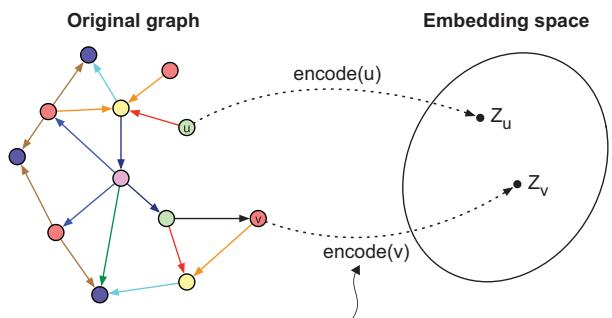

*그림 11.1 — 노드 임베딩 문제. 목표는 노드를 다차원 임베딩 공간으로 사상하는 인코딩 함수 $\mathrm{encode}(x)$ 를 학습하는 것이다. 임베딩 공간에서의 **거리** 가 원래 그래프의 관련 특성(예: 노드들의 상대적 위치)을 반영하도록 최적화한다. 이 그림의 `encode` 가 11.2 절 인코더–디코더 틀의 왼쪽 절반이고, 이 노트북의 node2vec 실행이 그 구체적 사례다.*

---

#### 임베딩의 기하학 — 평평한 공간을 넘어서

머신러닝의 근본 문제 하나: **데이터 종류마다 타고난 구조가 다르다.** 이미지의 모든 픽셀은 (경계를 빼면) 이웃이 여덟 개이고, 텍스트의 모든 단어는 앞뒤로 하나씩을 갖는다. 이 규칙성 덕분에 CNN·RNN 같은 기법이 성립한다. 그러나 그래프에서는 노드마다 연결 개수와 이웃 구조가 제각각이다.

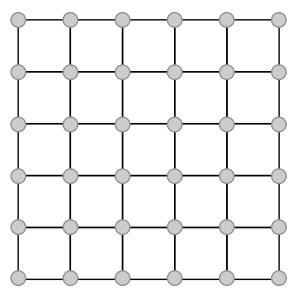 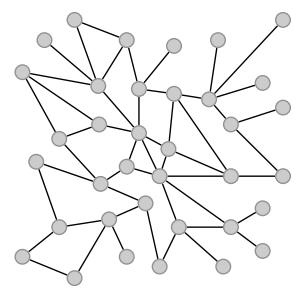

*그림 11.2 — 유클리드 공간(왼쪽)과 비유클리드 공간(오른쪽). 이미지의 픽셀들은 서로 같은 거리만큼 떨어져 있고 이웃이 여덟 개로 일정하다. 그래프에서는 이웃의 개수가 노드마다 엄청나게 다르다. 이 불규칙성이 11.5 절 메시지 전달이 "가변 개수의 이웃을 합(summation)으로 다룬다"고 설계된 이유다.*

**유클리드 공간(Euclidean space)** 에서는 거리를 직선으로 재고 피타고라스 정리가 성립한다. 두 점 $x, y \in \mathbb{R}^d$ 사이 거리는

$$d(x, y) = \sqrt{\sum_{i=1}^{d} (x_i - y_i)^2}$$

이다. 여기서 $d$ 는 임베딩 차원 수, $x_i$ 는 벡터 $x$ 의 $i$ 번째 좌표다. 대부분의 ML 모델이 이 공간을 가정하므로 기본 선택지가 된다.

그런데 **계층적(hierarchical)** 구조는 이야기가 다르다. 유클리드 공간은 중심에서 바깥으로 나아갈수록 쓸 수 있는 공간이 **다항식적으로** 늘어난다.

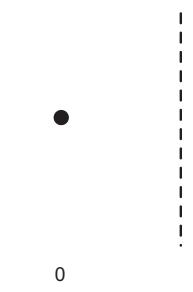 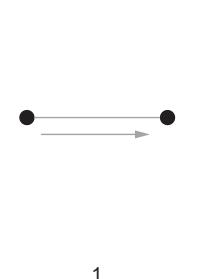 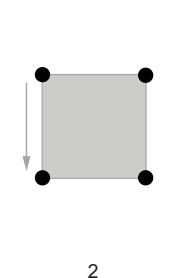 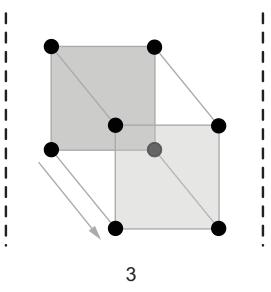

*그림 11.3 — 차원을 0 → 1 → 2 → 3 으로 늘려도 각 축을 따라 쓸 수 있는 공간은 지수적이 아니라 **다항식적으로** 늘어난다. 단위 정사각형(2D)의 넓이도 1, 단위 정육면체(3D)의 부피도 1, 단위 초입방체(4D)의 초부피도 1이다. 반면 **쌍곡 공간(hyperbolic space)** 은 바깥으로 갈수록 공간이 **지수적으로** 늘어난다 — 나무가 단계마다 더 많이 가지를 뻗듯이. 그래서 분기 수가 지수적으로 늘어나는 계층 구조를 훨씬 적은 차원으로 담아낼 수 있다.*

| | 유클리드 공간 | 쌍곡 공간 |
| --- | --- | --- |
| 벡터 | 단순한 좌표점 (예: `(0.5, 0.3)`) | 좌표로 표현하지만 행동이 다르다 |
| 거리 | 좌표 차이에 따라 선형적으로 증가 | 경계에 가까워질수록 지수적으로 증가 |
| 같은 좌표 차이 | 위치와 무관하게 같은 거리 | 경계 근처일수록 더 큰 거리 |
| 유사도 계산 | 표준 유클리드 거리 | **특수한 거리 공식이 필요** |
| 언제 쓰나 | 대부분의 응용 (기본값) | 계층 구조라는 **강한 증거** 가 있을 때만 |

계층 구조의 예: 기업 조직도, 생물학적 분류 체계, 인터넷 네트워크 위상, 의료 용어 체계. 다만 비유클리드 임베딩을 쓰면 거리 계산부터 시각화·해석까지 파이프라인 전체가 영향을 받는다. 이 관점은 **기하 딥러닝(GDL, geometric deep learning)** 이라는 더 넓은 분야에 속한다.

---

#### 지역 대 전역 — 위치적 임베딩과 구조적 임베딩

"그래프 구조의 **어떤 측면** 을 보존할 것인가"라는 질문에 대한 두 답이다.

| | **위치적 임베딩(positional)** | **구조적 임베딩(structural)** |
| --- | --- | --- |
| 보존하는 것 | 네트워크에서의 **절대적 위치** — 누가 중심인가, 누가 다리인가, 몇 걸음 떨어졌나 | **상대적 역할·지역 패턴** — 멀리 떨어져 있어도 교우 패턴이 닮았으면 비슷하게 |
| 대표 기법 | 행렬 분해, **랜덤 워크** | **GNN** |
| 잘 맞는 과제 | 비지도 — 링크 예측, 클러스터링 | 지도 — 노드 분류, 전체 그래프 분류 |
| 이 장에서 | 11.3 절 얕은 임베딩(node2vec) | 11.5\~11.6 절 GNN |

두 사람이 각자 다른 친구 무리의 **모임 주최자** 라면, 네트워크상 아무리 멀어도 구조적 임베딩은 이 둘을 비슷하게 표현한다. 위치적 임베딩은 그렇지 않다. 최근에는 이 경계가 흐려지고 있고(위치적 GNN 등), 두 관점이 서로 **보완적** 이라는 이론적 연구도 나왔다.

---

#### 학습 전략 — 전이적 접근과 귀납적 접근

"모델은 **처음 보는 데이터** 를 어떻게 다뤄야 하는가"라는 질문이다. 새 노드와 엣지가 계속 생기는 그래프에서 특히 중요하다.

| | **전이적(transductive)** | **귀납적(inductive)** |
| --- | --- | --- |
| 비유 | 특정 퍼즐 하나를 푸는 법을 배움 | 퍼즐 푸는 **일반 전략** 을 배움 |
| 최적화 대상 | 임베딩 자체 (고정된 노드 집합) | **매개변수적 사상**(parametric mapping) |
| 새 노드 | **불가** — 전체 재학습 필요 | 가능 — 학습된 사상을 그대로 적용 |
| 잘 맞는 그래프 | 정적 | 동적 |
| 이 장에서 | 11.3 절 얕은 임베딩 | 11.5 절 GNN |

전자상거래 추천이 좋은 예다. 기존 사용자에게 기존 상품을 추천하는 데는 전이적 접근으로 충분하다. 그러나 **새 사용자가 가입** 하면, 그 사람의 초기 상호작용과 프로필로부터 임베딩을 만들어 낼 귀납적 접근이 필요하다. 이 노트북의 **실습 11-B** 가 전이적 한계를 실제 예외로 확인한다.

---

#### 지도(supervision)의 역할

**비지도 학습** 은 대화 내용은 모른 채 누가 누구와 이야기하는지만 보고 무리의 사회적 역학을 파악하는 것과 같다. 그래프 구조 그 자체만으로도 값진 정보를 담고 있다는 가정에 의존하는데, 실제로 이 가정은 자주 참이다. **지도 학습** 은 그 상호작용에 대한 추가 맥락(레이블)을 갖고 학습을 특정 목표 쪽으로 이끄는 것이다.

---

#### 11.1.2 현실 세계의 응용

지금까지의 네 축(기하 · 위치/구조 · 전이/귀납 · 지도/비지도)이 실제로 어떻게 조합되는지 보여 주는 사례들이다.

| 응용 | 기하 | 위치/구조 | 전이/귀납 | 지도 |
| --- | --- | --- | --- | --- |
| **소셜 네트워크**(LinkedIn) | 유클리드 | 구조적 = 산업이 달라도 비슷한 직무 식별 · 위치적 = 인플루언서·다리 역할 식별 | **귀납적 필수** (새 사용자) | 직함·스킬로 추천 정확도 향상 |
| **생물학적 네트워크**(단백질 상호작용) | **쌍곡**(계층적 조직) | — | **귀납적 필수** (새 발견 반영) | 실험 데이터로 예측 정확도 향상 |
| **의료 지식 그래프** | **쌍곡**(용어 계층) | 구조적 = 분야가 달라도 유사 개념 식별 | — | 전문가 레이블로 관계 정확도 확보 |

임베딩 전략의 선택은 단순한 기술적 결정이 아니라 **문제 구조에 대한 이해** 를 반영한다.


---
### 11.2 인코더–디코더 모델 — 그래프 임베딩을 하나로 묶는 틀

11.1 절은 임베딩을 나누는 **축** 들을 보여 줬다. 그런데 축이 넷이나 되면 방법마다 따로 이해해야 할 것 같다. 인코더–디코더 모델이 이 부담을 없앤다. **행렬 분해든 랜덤 워크든 GNN 이든 전부 "인코딩 후 디코딩"이라는 같은 패턴의 다른 구현** 으로 볼 수 있다는 것이 이 절의 주장이다.

번역 시스템에 비유하면 좋다. 먼저 그래프 정보를 더 압축적이고 표준화된 표현으로 **변환(인코딩)** 하고, 그다음 그 표현을 **번역(디코딩)** 해 의미 있는 그래프 속성을 복원한다.

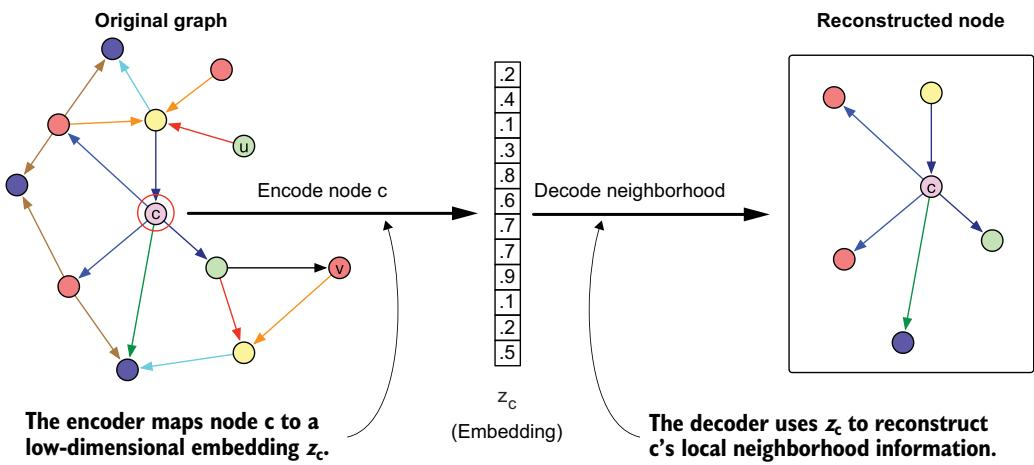

*그림 11.4 — 인코더–디코더 접근의 개요. 인코더는 노드 $c$ 를 저차원 임베딩 $z_c$ 로 사상하고, 디코더는 $z_c$ 를 사용해 $c$ 의 **지역 이웃 정보** 를 복원한다. 오른쪽 "Reconstructed node" 가 원래 그래프의 $c$ 주변과 얼마나 닮았는지가 곧 학습 신호다. 아래 11.2.4 절의 node2vec 이 이 그림의 구체적 사례다.*

#### 11.2.1 인코더 — 그래프 구조를 벡터로 바꾸기

인코더는 두 가지를 입력으로 받는다.

| 입력 | 설명 |
| --- | --- |
| **그래프 구조** | 노드들이 어떻게 연결되어 있는지 보여 주는 **인접 행렬(adjacency matrix)** |
| **노드 특징** | 각 노드의 속성에 대한 추가 정보 (있을 수도, 없을 수도) |

인코더의 흥미로운 점은 **유연성** 이다. 각 노드에 벡터를 할당하는 단순한 **룩업 테이블** 만큼 간단할 수도 있고(→ 11.3 절 얕은 임베딩), 구조와 특징을 모두 처리하는 신경망만큼 정교할 수도 있다(→ 11.5 절 GNN). 어떤 방법은 전역 구조와 상대적 위치 보존에, 다른 방법은 지역적 이웃 패턴 포착에 우선순위를 둔다 — 11.1 절의 위치적/구조적 구분이 여기서 다시 나타난다.

#### 11.2.2 디코더 — 그래프 속성을 복원하기

디코더의 과제는 **무엇을 보존하고 싶은가** 에 따라 달라진다.

| 보존 대상 | 디코더가 하는 일 |
| --- | --- |
| 그래프 구조 | 두 노드가 원래 그래프에서 **연결되어 있었는지** 예측 |
| 노드 유사성 | 노드들 사이 **이웃 겹침(neighborhood overlap)** 정도를 복원 |
| 추가 지도가 있을 때 | 노드 **레이블** 이나 다른 속성을 예측 |

이 복원 과제가 곧 **학습 신호** 다. 디코더의 예측과 실제 그래프 속성 사이 차이를 최소화하면 인코더가 더 나은 표현을 배우게 된다. "임베딩이 좋다"는 말을 측정 가능한 목표로 바꾸는 장치가 바로 디코더다.

#### 11.2.3 이 틀의 힘

이 틀이 값진 이유는 두 가지다.

1. **통합** — 행렬 분해·랜덤 워크·GNN 을 같은 언어로 비교할 수 있다.
2. **트레이드오프의 가시화** — 단순한 인코더는 계산 효율이 좋지만 담아내는 패턴이 덜 복잡하고, 정교한 신경망 인코더는 더 풍부한 표현을 배우지만 더 많은 데이터와 계산을 요구한다. 이 교환 관계가 11.3 절(단순)과 11.5 절(정교)의 대비로 이어진다.

#### 11.2.4 Node2Vec — 인코더–디코더 틀의 한 예

9장에서 다룬 **가라테 클럽 네트워크** 를 다시 쓴다. 노드는 클럽 회원, 엣지는 회원 사이의 친분이고, 이 클럽은 **강사(노드 0)** 와 **관리자(노드 33)** 사이의 다툼으로 두 무리로 갈라졌다. 정답 파벌이 알려져 있으므로 임베딩이 무엇을 배웠는지 채점할 수 있다.

| 단계 | Node2Vec 이 하는 일 |
| --- | --- |
| **인코딩 ①** 랜덤 워크 생성 | 친분 네트워크를 따라 "산책"한다. 예: $0 \to 1 \to 2 \to 3$. 넓게 탐색(다른 사회적 무리 둘러보기)과 깊게 탐색(끈끈한 무리 안에 머물기) 사이 균형을 조절할 수 있다 |
| **인코딩 ②** 벡터 생성 | 산책에서 자주 가까이 등장하는 회원들이 비슷한 벡터를 받는다 |
| **디코딩** | 두 회원 $i, j$ 의 벡터로 "친구일 가능성"을 예측한다. **소프트맥스** 로 "회원 $i$ 의 벡터가 주어졌을 때 랜덤 워크에서 회원 $j$ 를 근처에서 볼 확률"을 묻는 것이다 |

이 과정이 드러내는 패턴 세 가지다.

| 패턴 | 임베딩에 나타나는 모습 |
| --- | --- |
| **커뮤니티 구조** | 분열 후 같은 파벌에 속한 회원들이 비슷한 벡터를 얻는다. 직접 친분뿐 아니라 더 넓은 커뮤니티 소속까지 담긴다 |
| **다리 역할 회원** | 양쪽 파벌 모두에 친구를 둔 회원은 중간적 위치를 반영하는 벡터를 얻는다. 잠재적 **중재자** 식별에 쓸 수 있다 |
| **리더 역할** | 강사와 관리자는 중심적이면서 서로 **대립하는** 뚜렷한 벡터를 얻는다 |

`walk_length`·`num_walks` 는 산책의 양을, `p`·`q` 는 산책의 **성격** 을 정한다. 책의 리스팅은 `p=1, q=1` 을 쓰는데 이는 편향 없는 순수 랜덤 워크다. `q` 를 키우면 출발점 근처를 맴돌아(BFS 성향) **구조적** 역할이 강조되고, `q` 를 줄이면 멀리 뻗어(DFS 성향) **위치적**·커뮤니티 정보가 강조된다. **실습 11-A** 에서 이 값을 직접 바꿔 본다.

> **저장소 파일과 책 사이의 용어 차이** — 저장소 파일 `13.1 ...` 은 노드 33 을 `president`(회장)라 부르고 변수도 `president_allies` 다. 최종 출간본은 같은 인물을 `administrator`(관리자)라 부른다. MEAP 에서 최종본으로 가며 용어를 다듬은 흔적이고, 코드 동작은 완전히 같다. 이 노트북은 **원본 파일을 수정하지 않고** 그대로 실행한다.


── 책 Listing 11.1  (13.1 Applying node2vec embeddings to Karate Club’s Network.py 전체 (97줄, 스크립트)) ──
    import networkx as nx
    import numpy as np
    from node2vec import Node2Vec
    import matplotlib.pyplot as plt
    from sklearn.manifold import TSNE
    
    G = nx.karate_club_graph()
    
    faction_labels = {
        0: 0, 1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0, 7: 0, 8: 0,
        9: 1, 10: 1, 11: 0, 12: 0, 13: 0, 14: 1, 15: 1, 16: 0,
        17: 0, 18: 1, 19: 0, 20: 1, 21: 0, 22: 1, 23: 1, 24: 1,
        25: 1, 26: 1, 27: 1, 28: 1, 29: 1, 30: 1, 31: 1, 32: 1,
        33: 1
    }
    nx.set_node_attributes(G, faction_labels, 'faction')
    
    node2vec = Node2Vec(
        G,
        dimensions=16,
        walk_length=10,
        num_walks=20,
        p=1,
        q=1,
        workers=4
    )
    
    model = node2vec.fit(window=5)
    ... (전체 97줄, head=28 로 잘랐다)

실행: 13.1 Applying node2vec embeddings to Karate Club’s Network.py


Computing transition probabilities:   0%|          | 0/34 [00:00<?, ?it/s]

Computing transition probabilities: 100%|██████████| 34/34 [00:00<00:00, 15274.89it/s]

Generating walks (CPU: 4): 100%|██████████| 5/5 [00:00<00:00, 2040.63it/s]


Similarity between instructor (0) and their close ally (1): 0.9670023
Similarity between instructor (0) and president (33): 0.75930774


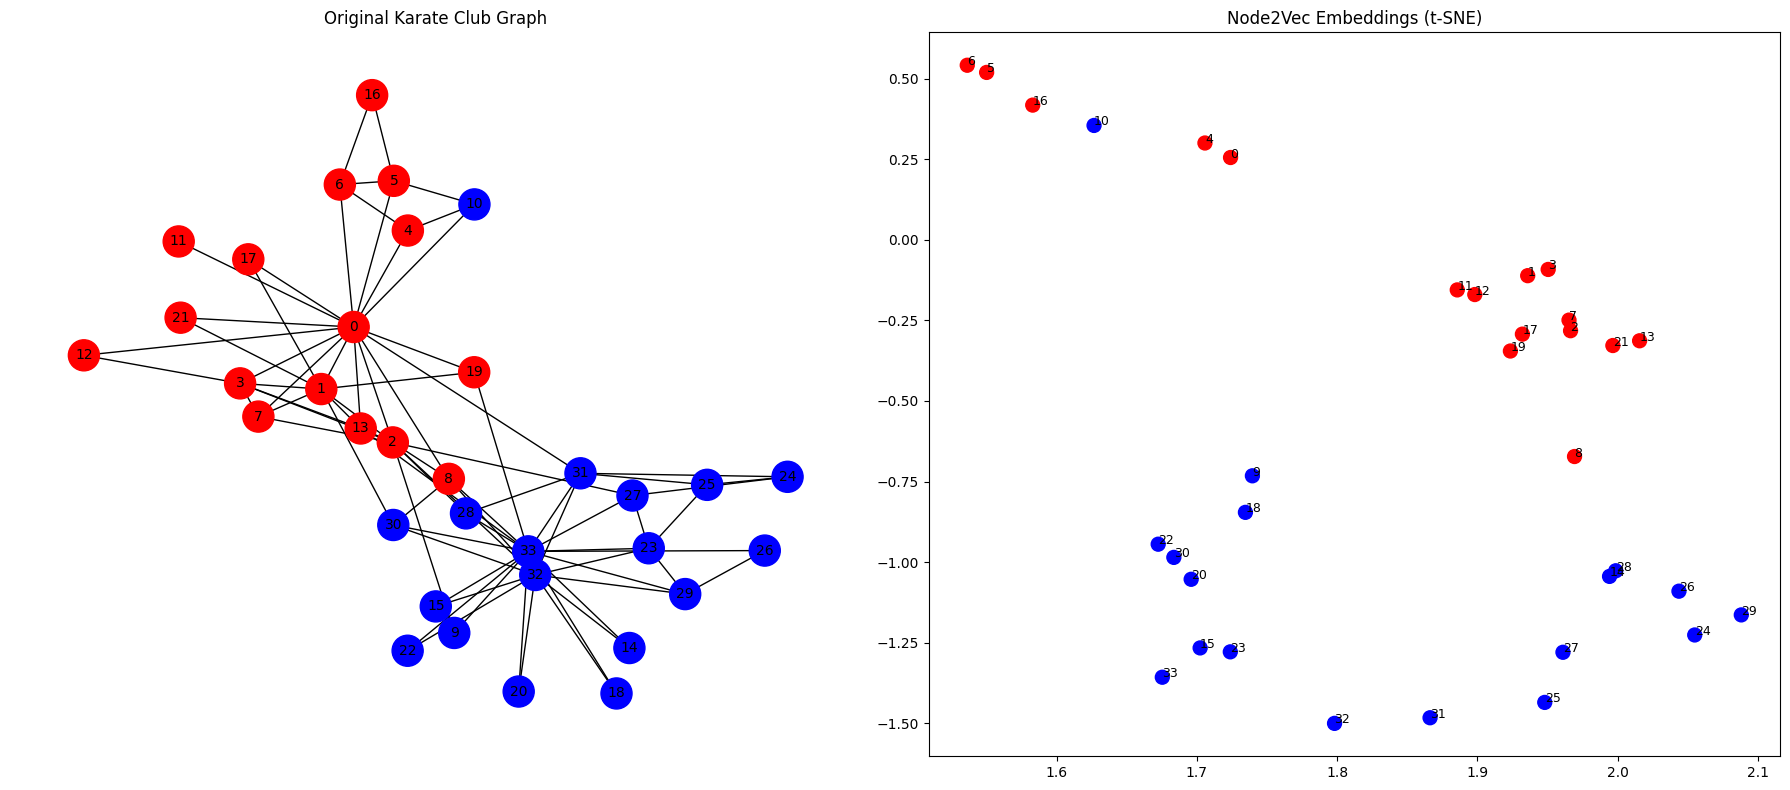


Predicted instructor's faction: [1, 2, 3, 4, 5, 6, 7, 10, 11, 12, 13, 16, 17, 19, 21]
Predicted president's faction: [8, 9, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]

소요 0.9초

── 실측값
    가라테 클럽 노드 수                                  34
    가라테 클럽 엣지 수                                  78
    임베딩 차원                                       16
    학습된 임베딩 개수                                   34
    node2vec 하이퍼파라미터                             dimensions=16, walk_length=10, num_walks=20, p=1, q=1, window=5
    유사도 sim(0, 1) — 강사와 측근                       0.9670000076293945
    유사도 sim(0, 33) — 강사와 관리자                     0.7592999935150146
    파벌 예측 정확도 (노드 0·33 제외 32개)                   30/32 = 93.8%
    오분류 노드                                       [8, 10]

── 읽는 법
  sim(0,1) 이 sim(0,33) 보다 크면, 랜덤 워크가 '같은 파벌은 서로 가깝다'는
  구조를 벡터 거리로 옮겨 담은 것이다. 이것이 그림 11.4 의 디코더가 하는 일이다.
  오분류가 남는 노드는 대개 두 파벌에 모두 친구를 둔 '다리 역할' 회원이다.


In [3]:
"""책 11.1 — 가라테 클럽 네트워크에 Node2Vec 임베딩을 적용한다.

이 셀은 저장소 파일을 **한 글자도 고치지 않고** 그대로 실행한다. runpy.run_path 를
쓰는 이유가 여기 있다.

  * tasks.run("node2vec") 은 별도 프로세스로 돌아서 학습된 model 객체를 노트북으로
    가져올 수 없고, plt.show() 도 창으로 뜬다.
  * 코드를 노트북에 옮겨 적으면 "책이 가르치는 리스팅을 다시 쓰는" 금지 사항에 걸린다.
  * runpy.run_path 는 파일을 이 커널 안에서 실행하므로 그림이 인라인으로 뜨고,
    끝난 뒤 model·G·파벌 예측을 그대로 꺼내 채점할 수 있다.

주의 두 가지.
  * node2vec 은 workers=4 로 여러 스레드에서 Word2Vec 을 학습한다. 스레드 스케줄링이
    비결정적이라 시드를 고정해도 유사도 값이 소수점 아래에서 조금씩 달라진다.
    아래 출력의 절대값보다 **부호와 대소 관계** 를 보라.
  * 34노드 그래프라 학습은 수 초면 끝난다. t-SNE 가 그중 대부분을 차지한다.
"""
import runpy
import time

show("11.1", head=28)   # 앞 28줄 — import·파벌 레이블·Node2Vec 설정까지
print()

script = listing_path("11.1")
print(f"실행: {script.name}")
started = time.time()
result = runpy.run_path(str(script))       # 원본 파일을 그대로 실행한다
elapsed = time.time() - started
print(f"\n소요 {elapsed:.1f}초")

# ---- 실행 결과에서 실측값을 꺼낸다 -------------------------------------------
MEASURED = {}

G = result["G"]
model = result["model"]
faction_labels = result["faction_labels"]
decode_similarity = result["decode_similarity"]

MEASURED["가라테 클럽 노드 수"] = G.number_of_nodes()
MEASURED["가라테 클럽 엣지 수"] = G.number_of_edges()
MEASURED["임베딩 차원"] = model.vector_size
MEASURED["학습된 임베딩 개수"] = len(model.wv)
MEASURED["node2vec 하이퍼파라미터"] = "dimensions=16, walk_length=10, num_walks=20, p=1, q=1, window=5"
MEASURED["유사도 sim(0, 1) — 강사와 측근"] = round(decode_similarity(model, 0, 1), 4)
MEASURED["유사도 sim(0, 33) — 강사와 관리자"] = round(decode_similarity(model, 0, 33), 4)

# 책이 analyze_community_structure 로 예측한 파벌을 정답과 대조한다.
# 정답(faction_labels)은 리스팅이 이미 정의해 두었으므로 새로 만들지 않는다.
predicted = {}
for node in result["instructor_group"]:
    predicted[node] = 0
for node in result["president_group"]:      # 저장소는 33 을 president 라 부른다
    predicted[node] = 1

correct = sum(1 for n, p in predicted.items() if faction_labels[n] == p)
MEASURED["파벌 예측 정확도 (노드 0·33 제외 32개)"] = f"{correct}/{len(predicted)} = {correct / len(predicted):.1%}"
MEASURED["오분류 노드"] = sorted(n for n, p in predicted.items() if faction_labels[n] != p)

print("\n── 실측값")
for key, value in MEASURED.items():
    print(f"    {key:<44} {value}")

print("\n── 읽는 법")
print("  sim(0,1) 이 sim(0,33) 보다 크면, 랜덤 워크가 '같은 파벌은 서로 가깝다'는")
print("  구조를 벡터 거리로 옮겨 담은 것이다. 이것이 그림 11.4 의 디코더가 하는 일이다.")
print("  오분류가 남는 노드는 대개 두 파벌에 모두 친구를 둔 '다리 역할' 회원이다.")


위 그림 두 장을 나란히 보는 것이 이 리스팅의 핵심이다.

| 왼쪽 그림 | 오른쪽 그림 |
| --- | --- |
| `spring_layout` 으로 그린 **원래 그래프**. 색은 정답 파벌(빨강 = 강사 쪽, 파랑 = 관리자 쪽) | 16차원 임베딩을 t-SNE 로 2차원에 투영한 **임베딩 공간**. 색은 같은 정답 파벌 |
| 위치는 엣지가 만드는 물리적 힘의 결과다 | 위치는 **랜덤 워크 동거 빈도** 의 결과다 |

오른쪽에서 같은 색이 뭉쳐 있다면, 인코더가 "누가 누구와 자주 함께 등장하는가"만 보고도 파벌 경계를 벡터 거리로 재현한 것이다. **정답 레이블을 학습에 쓰지 않았다는 점** 이 중요하다 — `faction_labels` 는 노드에 속성으로 붙어 색칠에만 쓰이고 `Node2Vec` 생성자에는 들어가지 않는다. 즉 이것은 11.1 절이 말한 **비지도 학습** 이다.

> **t-SNE 는 거리를 보존하지 않는다.** t-SNE 는 이웃 관계를 보존하도록 설계된 시각화 도구다. 오른쪽 그림에서 두 점 사이의 **절대 거리** 를 읽어 "이 둘의 유사도가 이만큼"이라고 해석하면 안 된다. 유사도는 반드시 원래 16차원 공간에서 `decode_similarity` 로 재야 한다. 군집이 몇 개로 갈리는지, 어떤 점이 두 군집 사이에 놓이는지 정도가 t-SNE 로 읽어도 되는 정보다.

두 군집 **사이** 에 놓인 점을 찾아보라. 11.2.4 절이 말한 **다리 역할 회원** 이고, 위 셀이 출력한 오분류 노드와 상당 부분 겹친다. 이 노드들은 모델의 실패가 아니라 네트워크의 실제 모호함이다.


---
### 11.3 얕은 임베딩 — 그래프 표현으로 가는 첫 접근

방금 돌린 node2vec 이 **얕은 임베딩(shallow embedding)** 이다. 인코더–디코더 틀의 가장 직접적인 구현이고, 그 단순함에 따라오는 한계가 바로 11.5 절 GNN 을 낳았다. 이 절은 "우리가 이미 돌려 본 것이 무엇이었나"를 되짚어 이름 붙이고, 그 한계를 네 가지로 정리한다.

#### 11.3.1 얕은 임베딩 이해하기

얕은 임베딩에서 인코더가 하는 일은 딱 하나다. **룩업 테이블(lookup table)** 로 동작하며 각 노드를 그에 해당하는 벡터로 곧바로 사상한다. 사전(dictionary)과 같다 — 각 단어(노드)가 자기 전용 항목(벡터)을 갖는다.

$$\mathrm{ENC}(v) = \mathbf{Z}[v]$$

여기서 $\mathbf{Z} \in \mathbb{R}^{|V| \times d}$ 는 임베딩 행렬이고, $|V|$ 는 노드 수, $d$ 는 임베딩 차원, $\mathbf{Z}[v]$ 는 노드 $v$ 에 해당하는 **행** 이다. 인코딩 요청을 받으면 그 행을 반환한다. 입력에 대한 깊은 처리나 변환이 전혀 없고 직접적인 룩업뿐이라서 **"얕다"** 고 부른다.

방금 실행한 코드에서 이 행렬을 눈으로 확인할 수 있다. `model.wv` 가 바로 $\mathbf{Z}$ 이고, `model.wv["17"]` 이 $\mathbf{Z}[17]$ 이다. 학습 후에는 34 × 16 짜리 표 하나만 남는다.

디코더는 이 벡터들을 받아 그래프의 중요한 속성(두 노드가 연결되어 있는지, 이웃이 얼마나 비슷한지)을 복원하려 한다. 이 복원 과제가 훈련 중에 임베딩 벡터를 밀고 당겨 그래프 구조의 의미 있는 패턴을 담아내게 만든다. 가라테 클럽에서는 자주 상호작용하는 회원끼리 비슷한 벡터를, 거의 상호작용하지 않는 회원끼리 서로 다른 벡터를 갖게 조정된다.

#### 11.3.2 얕은 임베딩의 한계 — 네 가지

| 한계 | 무슨 문제인가 | 가라테 클럽에서 |
| --- | --- | --- |
| **매개변수 비효율성** | 노드마다 별도 벡터가 필요하므로 매개변수 수가 노드 수에 **선형적으로** 비례한다. $\lvert V \rvert \times d$ 개 | 34 × 16 = 544개. 사용자 100만 명이면 1,600만 개 |
| **매개변수 공유 없음** | 노드 사이에 매개변수를 공유하지 않아, 그래프의 다른 부분에 나타나는 **공통 패턴** 을 활용하지 못한다 | 두 회원이 서로 다른 무리에서 비슷한 역할(주최자)을 맡아도, 모델은 그 패턴을 재사용하지 못하고 회원마다 독립적으로 학습한다 |
| **특징 무지(feature blindness)** | **노드 속성** 을 활용할 방법이 없다 | 회원의 나이·관심사·역할을 알아도 임베딩에 반영할 자리가 없다. `Node2Vec` 생성자에 노드 특징을 넣는 인자가 아예 없다 |
| **전이적 성격** | 훈련 중 존재했던 노드에 대해서만 임베딩을 만들 수 있다. 새 노드는 **전체 재학습** 이 필요하다 | 새 회원이 가입하면 룩업 테이블에 그 행이 없다. **실습 11-B** 에서 이 예외를 직접 발생시킨다 |

이 넷을 한 문장으로 줄이면 이렇다. **얕은 임베딩은 "각 노드가 무엇인지"를 외우고, GNN 은 "노드를 임베딩으로 바꾸는 방법"을 배운다.** 앞의 것은 사실의 목록이고 뒤의 것은 함수다. 함수를 배우면 매개변수를 공유할 수 있고, 노드 특징을 입력으로 받을 수 있고, 처음 보는 노드에도 적용할 수 있다. 위 표의 네 한계가 모두 여기서 한꺼번에 풀린다.

그렇다고 얕은 임베딩이 쓸모없어진 것은 아니다. GRL 의 근본적 어려움을 이해하게 해 주고, 더 정교한 접근을 비교할 **기준선(baseline)** 을 제공한다. 그래프가 비교적 작고 정적이며 계산 자원이 제한적인 상황에서는 여전히 실용적이다 — 방금 34노드 그래프를 수 초에 처리한 것이 그 예다.


---
### 11.4 지식 그래프에서의 임베딩

지금까지의 그래프는 엣지가 **한 종류** 였다. 가라테 클럽의 엣지는 전부 "친분"이다. 그런데 이 책이 계속 다뤄 온 지식 그래프는 그렇지 않다. 노드가 약물·질병·유전자·단백질이고 이들을 잇는 관계 종류가 수십 가지인 **다중 관계 그래프(multirelational graph)** 다. 11.4 절은 얕은 임베딩을 그런 그래프로 확장한다. 특히 엔티티 사이의 **빠진 관계를 예측** 하는 **KG 완성(KG completion)** 에서 중요하다.

단순한 그래프에서는 엔티티가 연결됐는지만 신경 쓰면 됐다. KG 에서는 **연결의 종류** 가 결정적이다. 생의학 KG 의 삼중항 세 개를 보자.

| 삼중항 | 뜻 |
| --- | --- |
| `(Aspirin, TREATS, Headache)` | 아스피린은 두통을 치료한다 |
| `(Aspirin, INHIBITS, COX-2)` | 아스피린은 COX-2를 억제한다 |
| `(Inflammation, CAUSES, Headache)` | 염증은 두통을 일으킨다 |

임베딩이 "관계가 있는가"뿐 아니라 "**어떻게** 관계가 있는가"까지 인코딩해야 한다. 그러려면 두 부품이 필요하다 — 임베딩이 구조를 얼마나 잘 담았는지 재는 **손실 함수** 와, 관계 종류를 구분하는 **다중 관계 디코더** 다.

---

#### 11.4.1 손실 함수

가장 단순한 발상은 예측한 연결과 실제 구조를 평균 제곱 오차로 직접 비교하는 것이다. 두 가지 이유로 안 된다.

| 문제 | 규모 |
| --- | --- |
| **계산 효율성** | 가능한 모든 노드 쌍을 비교해야 한다. 사용자 100만 명이면 잠재적 연결이 거의 **1조 개** 다 |
| **희소성(sparsity)** | 현실 그래프는 대부분 희소하다. 친구가 수백 명이어도 전체 수백만 명에 비하면 극소수다. 손실 함수가 이 불균형을 다뤄야 한다 |

그래서 현대적 접근은 **부정 표본 추출(negative sampling)** 과 교차 엔트로피 손실을 함께 쓴다. 참인 관계에는 높은 점수를, 가짜 관계에는 낮은 점수를 주도록 임베딩을 밀어붙이는 총 손실이다.

$$\mathcal{L} = \sum_{( u , \tau , v ) \in \mathcal{E} } - \log ( \sigma ( \mathrm{DEC} ( z_{u} , \tau , z_{v} ) ) ) - \gamma \mathbb{E}_{v_{n} \sim \hat{p}_{n , v} ( v ) } \left[ \log ( \sigma ( - \mathrm{DEC} ( z_{u} , \tau , z_{v_{n} } ) ) ) \right]$$

기호를 하나씩 풀면 이렇다.

| 기호 | 뜻 |
| --- | --- |
| $\mathcal{L}$ | 최소화하려는 **총 손실** |
| $\sum_{(u,\tau,v) \in \mathcal{E}}$ | KG 에 **존재하는 모든 엣지** 에 대한 합. $\mathcal{E}$ 는 엣지 집합 |
| $u$ | **머리 노드(head node)** — 예: `Aspirin` |
| $\tau$ | **관계 종류**(타우) — 예: `TREATS` |
| $v$ | **꼬리 노드(tail node)** — 예: `Headache` |
| $z_u$, $z_v$ | 노드 $u$, $v$ 의 **임베딩 벡터** |
| $\mathrm{DEC}$ | **디코더 함수**. 어떤 관계가 얼마나 그럴듯한지 점수를 매긴다 |
| $\sigma$ | **시그모이드**. 점수를 0\~1 확률로 변환한다 |
| $\gamma$ | **균형 매개변수**(감마). 부정 표본의 중요도를 조절한다 |
| $v_n$ | **부정 표본**. 예: `Headache` 대신 뽑은 `COX-2` |
| $\hat{p}_{n,v}(v)$ | 부정 예시를 뽑는 데 쓰는 **분포** |
| $\mathbb{E}$ | 부정 표본들에 대한 **기댓값** |

두 항으로 나눠 보면 각각이 하는 일이 분명해진다.

**긍정 부분** — 실제로 존재하는 관계에 대한 손실이다.

$$- \log ( \sigma ( \mathrm{DEC} ( z_{u} , \tau , z_{v} ) ) )$$

$\mathrm{DEC}(z_u, \tau, z_v)$ 로 참인 관계의 점수를 계산하고, $\sigma$ 로 확률로 바꾸고, $-\log$ 를 씌운다. $-\log$ 는 확률이 1에 가까우면 0에, 0에 가까우면 무한대로 간다. 즉 **참인 관계를 낮게 평가하면 벌을 준다.**

**부정 부분** — 존재하지 않는 가짜 관계에 대한 손실이다.

$$- \gamma \mathbb{E}_{v_{n} \sim \hat{p}_{n , v} ( v ) } \left[ \log ( \sigma ( - \mathrm{DEC} ( z_{u} , \tau , z_{v_{n} } ) ) ) \right]$$

$\mathrm{DEC}$ 앞에 **마이너스** 가 붙은 것이 핵심이다. 가짜 관계에 낮은 점수를 주면 $-\mathrm{DEC}$ 가 커지고 $\sigma(-\mathrm{DEC})$ 가 1에 가까워져 손실이 작아진다. $\gamma$ 는 이 항의 중요도를 곱으로 조절한다.

"아스피린은 두통을 치료한다"는 사실 하나에 대해 손실 함수가 하는 일은 결국 둘이다.

| 항 | 하는 일 |
| --- | --- |
| 첫째 항 (긍정) | `(Aspirin, TREATS, Headache)` 에 **높은 점수** 를 주도록 격려 |
| 둘째 항 (부정) | 이 관계를 갖는다고 알려지지 않은 엔티티를 뽑아 — 예: `(Aspirin, TREATS, COX-2)`, `(Aspirin, TREATS, Inflammation)` — **낮은 점수** 를 주도록 격려 |

KG 는 보통 희소하다(가능한 대부분의 관계가 존재하지 않는다). 그래서 실무에서는 **$\gamma > 1$** 로 두어 가짜 관계를 정확히 가려내는 쪽을 강조한다. 이 손실은 가능한 모든 관계를 확인하지 않고 참인 관계와 소수의 부정 표본만 보므로 계산이 싸다 — 참인 관계 하나당 **부정 표본 5\~10개** 정도를 쓴다.

---

#### 부정 표본 추출의 기술

효과는 부정 예시를 **어떻게 고르느냐** 에 크게 좌우된다. 가장 단순하게 무작위로 뽑으면 `(Aspirin, TREATS, Laptop)` 이나 `(Aspirin, TREATS, Mountain)` 같은 것이 나온다. 계산은 싸지만 두 가지 한계가 있다.

| 한계 | 설명 |
| --- | --- |
| **거짓 부정(false negatives)** | 실제로 KG 에 있는 관계를 실수로 뽑을 수 있다. 걸러 내는 검사를 두는 시스템도 있다 |
| **지나치게 쉬운 예시** | 무작위 표본 상당수는 명백히 틀려서 모델이 의미 있는 패턴을 배우는 데 도움이 안 된다 |

그래서 더 정교한 전략이 나왔다.

| 전략 | 방법 | 효과 |
| --- | --- | --- |
| **유형 제약 표본 추출**(type-constrained) | `TREATS` 의 부정 표본은 **질병만** 에서 뽑는다 | 모델이 더 미묘한 구별을 학습하도록 강제 |
| **적대적 표본 추출**(adversarial) | 참인 관계와 **혼동될 가능성이 높은** 예시를 골라낸다 | 더 섬세한 이해를 갖추게 함 |

주어·목적어 중 무엇을 바꿀지도 선택 사항이다. `Aspirin TREATS Headache` 에 대해 치료제를 바꾸면 `Sunlight TREATS Headache`, 증상을 바꾸면 `Aspirin TREATS Happiness`, 둘 다 바꾸면 `Sunlight TREATS Happiness` 다. 실무에서는 **출발점과 도착점을 번갈아 바꾸는** 편이 편향을 막는다. 관계의 방향이 중요한 KG 에서 특히 그렇다.

---

#### 11.4.2 다중 관계 디코더

손실 함수를 갖췄으면 이제 관계 종류를 구분하는 디코더가 필요하다. KG 에는 다음 패턴들이 나타난다.

| 패턴 | 예 |
| --- | --- |
| **대칭 대 비대칭** | `similar_to` 는 대칭(A가 B와 비슷하면 B도 A와 비슷). `causes` 는 비대칭(A가 B를 일으켜도 B가 A를 일으키진 않는다) |
| **합성(compositional)** | 약물 A가 질병 B를 치료하고 B가 C의 한 종류면, A가 C를 치료한다고 추론할 수 있다 |
| **역관계(inverse)** | A가 B를 `contains` 하면 B는 A의 `part_of` 다 |

주요 접근 세 가지다.

| 접근 | 관계를 무엇으로 표현하나 | 강점 | 약점 |
| --- | --- | --- | --- |
| **번역 기반 (TransE)** | 한 엔티티를 다른 엔티티로 "옮기는" **벡터** — $z_{\text{Aspirin}} + z_{\text{TREATS}} \approx z_{\text{Headache}}$ | 가장 직관적. **합성 패턴** 에 뛰어나다 | 다대일(many-to-one) 관계에 약하다 |
| **행렬 기반 (RESCAL)** | 엔티티 벡터를 변환하는 **행렬** | 표현력이 크다 | 매개변수가 많다. 엔티티 1,000개 · 관계 100종이면 관계만으로 수백만 개 |
| **의미 매칭 (DistMult, ComplEx)** | 관계 종류를 고려한 **유사도 측정** | ComplEx 는 **복소수** 로 비대칭 관계를 우아하게 다룬다 | 합성 패턴은 그만큼 잘 담아내지 못할 수 있다 |

디코더 선택이 모델이 배울 수 있는 패턴의 종류를 결정한다. TransE 와 ComplEx 의 강약이 **정반대** 라는 점을 기억할 만하다 — 정답은 데이터에 어떤 패턴이 지배적인지에 달려 있다.

정교한 손실 함수와 다중 관계 디코더로 이루어진 이 틀이 현대 KG 임베딩의 토대다. 다만 여전히 **얕은 임베딩** 이라는 한계는 그대로 남아 있다 — 인코더는 아직 룩업 테이블이다. 다음 절이 그 인코더를 바꾼다.


---
### 11.5 메시지 전달과 그래프 신경망

11.3 절이 정리한 얕은 임베딩의 네 한계를 다시 보자. 매개변수 비효율성 · 공유 없음 · 특징 무지 · 전이적 성격. 이 넷의 공통 원인은 하나다 — **인코더가 룩업 테이블** 이라는 것. GNN 은 인코더를 **함수** 로 바꾼다. 그 함수의 이름이 **신경 메시지 전달(neural message passing)** 이다.

#### 11.5.1 메시지 전달 틀 — 신경망의 대화

메시지 전달을 그래프 전체에 걸쳐 벌어지는 **대화** 라고 생각하면 좋다. 사람이 사회적 무리와 대화하며 정보를 나누고 처리하듯, 노드도 이웃과의 구조화된 상호작용으로 정보를 나누고 갱신한다. 이 대화는 **여러 라운드** 에 걸쳐 일어나고, 각 라운드마다 정보가 그래프를 따라 한 걸음 더 멀리 이동한다.

핵심 통찰은 노드가 바로 옆 연결로부터만 배우는 것이 아니라, **반복적 갱신** 을 통해 더 넓은 구조로부터도 배운다는 점이다. 각 반복마다 모든 노드가 하는 일은 셋이다.

1. 이웃들로부터 메시지를 **모은다**
2. 그 메시지들을 **처리해** 관련 정보를 추출한다
3. 처리된 메시지를 바탕으로 자기 표현을 **갱신한다**

이것이 두 함수로 형식화된다.

| 함수 | 하는 일 |
| --- | --- |
| **AGGREGATE**(집계) | 이웃 노드들로부터 메시지를 모으고 결합한다 |
| **UPDATE**(갱신) | 집계된 메시지를 사용해 노드의 표현을 갱신한다 |

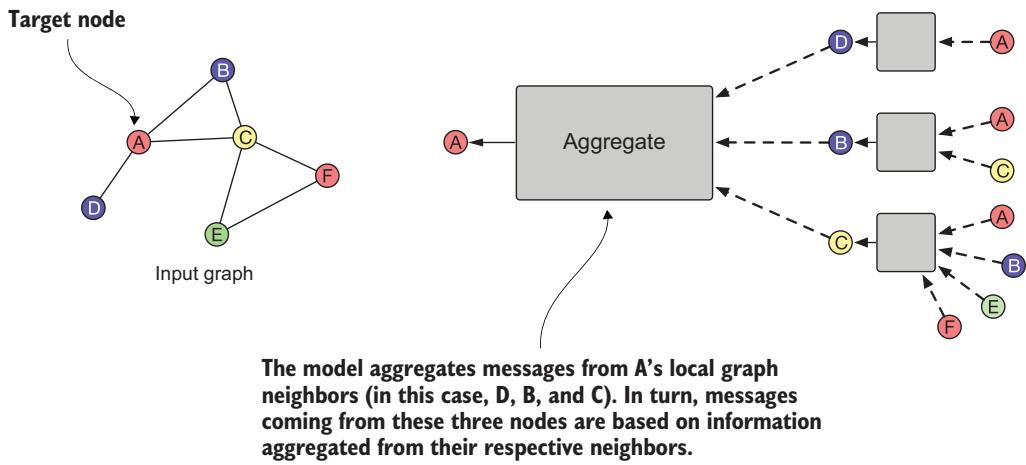

*그림 11.5 — 하나의 노드가 자신의 지역 이웃으로부터 메시지를 집계하는 방식. 대상 노드 A 는 D·B·C 에서 메시지를 받고, 그 셋은 각자 자신의 이웃(A·C·E·F 등)에서 메시지를 받는다. **GNN 의 계산 그래프가 대상 노드 주변의 이웃을 펼쳐 나가면서 트리 구조를 이룬다** 는 점에 주목하라. 이 트리의 깊이가 곧 반복 횟수 $k$ 이고, 뒤에 나오는 11.6 절 아키텍처들은 모두 이 트리의 각 합류 지점(집계)과 노드 자리(갱신)에서 무엇을 하느냐만 다르다.*

소셜 네트워크에서 사용자 관심사를 분석한다면 이렇게 진행된다.

| 라운드 | 사용자의 표현에 담기는 것 |
| --- | --- |
| 0 (초기) | 자기가 명시적으로 밝힌 관심사 |
| 1 | + 친구들의 관심사 |
| 2 | + 친구의 친구들의 관심사 |
| $k$ | + $k$ 걸음 안 사회적 무리의 관심사 패턴 |

#### 11.5.2 메시지 전달이 작동하는 이유

$k$ 번 반복하면 각 노드의 표현은 **$k$-홉 이웃** 의 정보를 담는다. 이 점진적 수집이 두 가지를 동시에 해낸다.

| 종류 | 무엇을 얻나 | 예 |
| --- | --- | --- |
| **구조적 정보** | 그래프의 **위상(topology)** 이 자연스럽게 인코딩된다 | 분자 그래프에서 여러 라운드 후, 한 원자의 표현이 "나는 벤젠 고리의 일부다"라는 정보를 담는다 |
| **특징 기반 정보** | 노드가 **이웃의 특징** 으로부터 배운다 | 인용 네트워크에서 한 논문의 표현이 관련 논문들의 정보를 흡수해 학문적 지형 안에서의 위치를 담는다 |

11.3 절의 네 한계와 대조해 보라. 함수 하나를 모든 노드에 적용하므로 **매개변수가 공유** 되고(한계 ①②), 초기 표현 $h_v^{(0)}$ 자리에 노드 특징을 넣을 수 있고(한계 ③), 학습된 함수를 처음 보는 노드에도 적용할 수 있다(한계 ④). 네 한계가 인코더를 함수로 바꾼 것 하나로 함께 풀린다.

#### 11.5.3 기본 GNN 모델

기본 GNN 은 반복 $k$ 에서 노드 $u$ 의 갱신 규칙을 이렇게 정의한다. 자신의 이전 표현과 이웃들의 표현을 각각 학습 가능한 가중치 행렬로 변환해 더한 뒤 비선형 함수를 통과시킨다.

$$h_{u}^{(k)} = \sigma \left( W_{\mathrm{self}}^{(k)} h_{u}^{(k-1)} + W_{\mathrm{neigh}}^{(k)} \sum_{v \in \mathcal{N}(u)} h_{v}^{(k-1)} + b^{(k)} \right)$$

| 기호 | 뜻 |
| --- | --- |
| $h_u^{(k)}$ | 반복 $k$ 에서 노드 $u$ 의 표현. $h_u^{(0)}$ 는 초기 노드 특징 |
| $W_{\mathrm{self}}^{(k)}$ | 학습 가능한 행렬. **노드 자신의** 이전 표현에 곱한다 |
| $W_{\mathrm{neigh}}^{(k)}$ | 학습 가능한 행렬. **이웃에서 집계한** 값에 곱한다 |
| $\mathcal{N}(u)$ | 노드 $u$ 의 이웃 집합 |
| $\sum_{v \in \mathcal{N}(u)} h_v^{(k-1)}$ | 모든 이웃 표현의 합. **개수가 노드마다 달라도 되는** 이유가 여기 있다 |
| $\sigma$ | 비선형 활성화 함수 (ReLU, tanh 등) |
| $b^{(k)}$ | 편향 항. 종종 생략된다 |

> **NOTE** — $W_{\mathrm{self}}$·$W_{\mathrm{neigh}}$·$b$ 는 메시지 전달 반복들 사이에서 **공유** 할 수도 있고 각 층(반복)마다 따로 훈련할 수도 있다. 공유하면 매개변수가 줄고 과적합이 억제되며, 따로 두면 층마다 다른 역할을 배울 수 있다.

이 모델은 표준 신경망 층과 거의 같다. **주된 차이는 고정 크기 입력 대신 가변 개수의 이웃을 합 연산으로 다룬다** 는 것뿐이다. 바로 이 점이 그림 11.2 오른쪽의 불규칙성 문제에 대한 답이다.

같은 식을 AGGREGATE 와 UPDATE 로 쪼개면 앞의 머릿속 그림과 맞아떨어진다. 먼저 집계는 이웃들의 표현을 하나로 합친다.

$$m_{\mathcal{N}(u)}^{(k-1)} = \mathrm{AGGREGATE}^{(k-1)} \left( \left\{ h_{v}^{(k-1)} , \forall v \in \mathcal{N}(u) \right\} \right) = \sum_{v \in \mathcal{N}(u)} h_{v}^{(k-1)}$$

$m_{\mathcal{N}(u)}^{(k-1)}$ 는 노드 $u$ 의 이웃들로부터 집계된 **메시지** 이고, 기본 모델에서는 그것이 단순히 이웃 표현들의 합이다. 그다음 갱신이 이 메시지와 자신의 이전 표현을 결합한다.

$$\mathrm{UPDATE} \left( h_{u}^{(k)} , m_{\mathcal{N}(u)}^{(k-1)} , b^{(k)} \right) = \sigma \left( W_{\mathrm{self}}^{(k)} h_{u}^{(k-1)} + W_{\mathrm{neigh}}^{(k)} m_{\mathcal{N}(u)}^{(k-1)} + b^{(k)} \right)$$

두 식은 앞의 통합 공식과 **같은 것** 을, 집계 단계와 갱신 단계로 나눠 표현한 것이다. 이 분리가 왜 중요한가? **11.6 절이 이 두 자리를 각각 교체 가능한 부품으로 다루기 때문이다.** 합 대신 평균·대칭 정규화·어텐션을 넣으면 집계가 바뀌고, 단순 덧셈 대신 연결·게이트·LSTM 을 넣으면 갱신이 바뀐다. GNN 아키텍처의 계보 전체가 이 두 슬롯의 조합표다.

#### 11.5.4 자기 루프를 사용한 메시지 전달

중요한 변형 하나는 그래프에 **자기 루프(self-loop)** 를 추가하는 것이다. AGGREGATE 와 UPDATE 를 따로 두는 대신, 집계할 때 각 노드를 자기 자신의 이웃으로 취급한다.

$$h_{u}^{(k)} = \mathrm{AGGREGATE}^{(k-1)} \left( \left\{ h_{v}^{(k-1)} , \forall v \in \mathcal{N}(u) \cup \{ u \} \right\} \right)$$

$\mathcal{N}(u) \cup \{u\}$ 가 핵심이다. 노드 $u$ 의 이웃 집합에 $u$ 자신을 더했으므로, 자기 표현도 집계에 함께 들어간다. $W_{\mathrm{self}}$ 와 $W_{\mathrm{neigh}}$ 가 하나로 합쳐지는 셈이다.

| 장점 | 트레이드오프 |
| --- | --- |
| AGGREGATE·UPDATE 를 합치므로 **구현이 단순** 하다 | 노드 자신의 정보를 이웃 정보와 **똑같이 취급** 하게 된다 |
| 매개변수 공유로 **과적합** 을 막는 데 도움이 된다 | 현재 상태와 이웃 정보를 어떻게 섞을지에 대한 **유연성을 잃는다** |
| 훈련 중 **안정성** 이 높아질 수 있다 | |

선택 기준은 명확하다. 노드 자신의 특징과 이웃의 특징을 **구별하는 것이 결정적인** 과제에서는 표준 접근이 낫고, 그 구별이 덜 중요하면 자기 루프 변형이 더 단순하고 견고하다. **12장의 예제들이 AGGREGATE·UPDATE 대신 이 자기 루프 방식을 쓴다.**


---
### 11.6 일반화된 집계와 갱신 방법

11.5 절은 AGGREGATE 와 UPDATE 라는 **두 개의 슬롯** 을 만들었다. 이 절은 그 슬롯에 무엇을 끼워 넣을 수 있는지를 다룬다. 전통적 신경망이 단순한 퍼셉트론에서 스킵 연결·어텐션·정규화 층을 갖춘 아키텍처로 진화했듯 GNN 도 같은 혁신을 받아들일 수 있다. 다만 그래프 구조 데이터의 고유한 성질 — **불규칙한 연결 패턴과 노드마다 다른 이웃 크기** — 을 존중하도록 맞춰야 한다.

#### 아키텍처 강화 세 가지 — 왜 필요한가

| 장치 | 일반 신경망에서 | GNN 에서 해결하는 문제 |
| --- | --- | --- |
| **스킵 연결(skip connection)** = 잔차 연결 | 정보가 층을 건너뛰는 지름길 | 여러 번 메시지 전달을 거치면 노드 표현이 서로 너무 비슷해지는 **과도한 평활화(over-smoothing)** 를 막는다. 기울기 흐름을 유지해 **깊은** GNN 을 가능하게 한다 |
| **어텐션(attention)** | 입력의 부분마다 다른 중요도 가중치 | 이웃의 기여를 **관련성에 따라 다르게** 가중해 선택적으로 집계한다 |
| **정규화 층(normalization)** | 층 출력 분포를 통제해 훈련 안정화 | **노드마다 이웃 개수가 크게 다르다.** 특징을 적절히 스케일링해 이 차이를 관리한다 |

과도한 평활화는 GNN 특유의 실패 모드다. 층을 깊게 쌓을수록 각 노드가 결국 그래프 전체를 집계하게 되어 모든 노드의 표현이 같은 값으로 수렴한다. 층을 늘리면 성능이 좋아지는 일반 신경망의 직관이 여기서는 통하지 않는다.

---

#### 11.6.1 이웃 정규화

기본 GNN 의 집계는 **합** 이었다. 이웃이 3개인 노드와 3,000개인 노드가 완전히 다른 크기의 값을 받는다는 뜻이다. 수치적 불안정이 생기고, 서로 다른 규모에 걸쳐 학습하기가 어려워진다.

가장 단순한 정규화는 합 대신 **평균** 을 취하는 것이다.

$$m_{\mathcal{N}(u)}^{(k-1)} = \frac{\sum_{v \in \mathcal{N}(u)} h_{v}^{(k-1)}}{\lvert \mathcal{N}(u) \rvert}$$

| 기호 | 뜻 |
| --- | --- |
| $h_v^{(k-1)}$ | 이웃 $v$ 로부터 오는 특징 벡터 |
| $\lvert \mathcal{N}(u) \rvert$ | 노드 $u$ 의 **이웃 개수**(차수) |

합은 벡터에 대해 이루어지므로 각 항목이 같은 위치의 다른 항목들과 더해진다. 이 수식의 구현이 저장소 `GNN_all_in_one.py` 의 `MeanAggregator` 다 — 책에는 번호가 붙지 않았지만 정확히 이 식을 계산한다. 패딩된 이웃을 평균에서 빼기 위해 마스크를 쓰는 것이 실무적 차이다.

더 정교한 방식으로 Kipf 와 Welling 이 그래프 합성곱 신경망(GCN)에서 널리 알린 **대칭 정규화(symmetric normalization)** 가 있다.

$$m_{\mathcal{N}(u)}^{(k-1)} = \sum_{v \in \mathcal{N}(u)} \frac{h_{v}^{(k-1)}}{\sqrt{\lvert \mathcal{N}(u) \rvert \lvert \mathcal{N}(v) \rvert}}$$

각 이웃 $v$ 의 기여가 **$u$ 의 차수와 $v$ 의 차수를 곱한 값의 제곱근** 으로 나뉜다. 즉 보내는 쪽과 받는 쪽 **양쪽** 의 차수가 메시지 강도를 정한다. 인용 네트워크가 좋은 예다. 수천 번 인용된 논문($\lvert \mathcal{N}(v) \rvert$ 가 크다)이 메시지 전달을 지배하지 않도록 그 영향을 자동으로 깎는다. 여러 분야에서 널리 인용된 논문이라고 해서 더 전문적이고 관련성 높은 인용보다 반드시 강한 영향을 미쳐야 할 이유가 없기 때문이다.

| 방식 | 무엇을 고려하나 | 언제 쓰나 |
| --- | --- | --- |
| **평균 정규화** | 받는 노드의 차수만 | 이웃 수가 다른 노드들을 같은 척도로 비교하고 싶을 때 |
| **대칭 정규화** | 보내는 노드와 받는 노드의 차수 모두 | 방향 그래프, 또는 노드 중요도 편차가 큰 그래프 |
| **학습된 정규화 계수** | 모델이 훈련 중 스스로 조정 | 위 둘이 부족할 때 |

> **정규화는 손실이 있는(lossy) 연산이다.** 정규화 후에는 학습된 임베딩으로 **차수가 다른 노드를 구별하기 어려워진다.** 차수 자체가 신호인 과제(예: 허브 탐지)에서는 정규화가 오히려 해롭다. 정규화가 가장 도움이 되는 상황은 두 가지다 — 노드 **특징** 정보가 구조 정보보다 훨씬 유용한 과제이거나, 노드 차수의 범위가 너무 넓어 최적화가 불안정해지는 경우다.

---

#### 11.6.2 이웃 어텐션

정규화는 이웃 크기 문제를 풀었지만, 정규화된 기여 **안에서는 모든 이웃을 똑같이** 취급한다. 그러나 그래프의 모든 관계가 같은 중요도를 갖지는 않는다. 소셜 네트워크에서 어떤 친분은 사용자의 관심사를 예측하는 데 다른 친분보다 훨씬 관련이 깊다.

**어텐션(attention)** 은 이웃마다 **학습 가능한** 가중치를 부여한다. 이 방식을 처음 적용한 GNN 이 Veličković 등의 **그래프 어텐션 네트워크(GAT)** 다.

$$m_{\mathcal{N}(u)}^{(k-1)} = \sum_{v \in \mathcal{N}(u)} \alpha_{u,v} \, h_{v}^{(k-1)}$$

$\alpha_{u,v}$ 는 노드 $u$ 에서 정보를 집계할 때 이웃 $v \in \mathcal{N}(u)$ 에 두는 **주의 가중치** 다. 앞의 평균 정규화가 모든 $\alpha_{u,v}$ 를 $1/\lvert \mathcal{N}(u) \rvert$ 로 고정한 특수한 경우라고 보면 관계가 분명해진다. GAT 원 논문의 정의는 이렇다.

$$\alpha_{u,v} = \frac{\exp \left( a^{T} \left[ W h_{u} \bigoplus W h_{v} \right] \right)}{\sum_{v' \in \mathcal{N}(u)} \exp \left( a^{T} \left[ W h_{u} \bigoplus W h_{v'} \right] \right)}$$

| 기호 | 뜻 |
| --- | --- |
| $a$ | 학습 가능한 **어텐션 벡터** |
| $W$ | 학습 가능한 **행렬**. $h_u$·$h_v$ 를 같은 공간으로 변환한다 |
| $\bigoplus$ | **연결(concatenation)** 연산. $W h_u$ 와 $W h_v$ 를 이어 붙인다 |
| 분자 | $u$ 와 $v$ 의 변환된 특징을 이어 붙여 $a$ 와 내적하고 지수를 취한 값 |
| 분모 | $u$ 의 **모든** 이웃 $v'$ 에 대해 같은 계산을 한 값들의 합 |

분모가 하는 일이 곧 **소프트맥스** 다 — 가중치들의 합이 1이 되도록 정규화한다. 어텐션은 이웃 중요도가 과제·맥락에 따라 크게 달라질 때, 그래프에 잡음이나 무관한 연결이 있을 때, 노드 사이 관계가 복잡하고 비선형일 때 특히 값지다.

---

#### 11.6.3 멀티헤드 어텐션과 트랜스포머와의 연결

지금까지의 어텐션은 자연어 처리를 바꿔 놓고 LLM 의 근간이 된 **트랜스포머(transformer)** 와 깊은 연결을 공유한다. 트랜스포머가 문장 속 각 단어를 다른 모든 단어에 주의를 기울이게 하듯, GAT 는 각 노드가 자신의 이웃에 선택적으로 주의를 기울이게 한다.

그런데 어텐션 메커니즘 **하나** 로는 데이터의 관련 패턴을 모두 담아내기 어렵다. 이 통찰이 두 분야 모두에서 **멀티헤드 어텐션(multihead attention)** 을 낳았다. 여러 개의 독립적인 어텐션을 병렬로 두고, 각 헤드가 이웃 관계의 서로 다른 측면에 집중하도록 학습한다. 분자 그래프라면 한 헤드는 화학 결합 유형에, 다른 헤드는 공간적 배치에 집중할 수 있다.

**책 리스팅 11.2 · 11.3 · 11.4 가 이 아이디어의 구현** 이고, 아래 코드 셀이 저장소 원문을 보여 준 뒤 실제로 순전파를 돌린다.

| 책 리스팅 | 클래스 | 무엇을 보여 주나 |
| --- | --- | --- |
| **11.2** | `MultiHeadGraphAttention` | 특징 차원을 헤드 수만큼 조각으로 나눠 병렬 처리하고 출력을 이어 붙인다 |
| **11.3** | `TransformerStyleGraphAttention` | Q·K·V 행렬로 스케일링된 점곱 어텐션을 계산한다 — 트랜스포머와 같은 연산 |
| **11.4** | `StructuralGraphTransformer` | 트랜스포머의 **위치 인코딩** 에 대응하는 **구조적 인코딩** 을 노드 차수로 만들어 특징에 더한다 |

트랜스포머 스타일 어텐션이 GNN 에 주는 이점 세 가지다.

| 이점 | 설명 |
| --- | --- |
| **규모와 효율성** | 계산을 병렬화해 큰 이웃을 효율적으로 처리한다 |
| **유연한 특징 학습** | 각 헤드가 서로 다른 종류의 관계·패턴에 특화될 수 있다 |
| **해석 가능성** | 어텐션 가중치가 "어떤 이웃 관계가 중요했나"를 보여 준다 |

##### ⚠️ 책에 인쇄된 코드와 저장소 코드가 다르다 — 그리고 책 쪽이 그대로는 돌지 않는다
 이 노트북이 굳이 저장소 클래스를 실행하는 이유이니 반드시 확인하고 넘어가라.

| 리스팅 | 책에 인쇄된 코드 | 저장소 코드 | 왜 책 쪽이 문제인가 |
| --- | --- | --- | --- |
| **11.2** | `self.head_dim = input_dim` | `input_dim // num_heads` + 나눗셈 가능 여부 `assert` | `torch.chunk(x, num_heads, dim=-1)` 은 특징 축을 `input_dim // num_heads` 크기로 쪼갠다. 헤드가 선언한 차원과 실제로 받는 차원이 어긋나 `nn.Linear` 에서 shape 오류가 난다 |
| **11.2** | `GraphAttentionHead` 를 호출하지만 **정의가 없다** | `GNN_all_in_one.py` L8-L34 에 정의 | 책만 보고 옮겨 적으면 `NameError` 가 난다 |
| **11.3** | `matmul(Q, K.transpose(-2,-1))` 에서 Q 가 `[batch, nodes, dim]` | `node_features.unsqueeze(2)` 로 `[batch, nodes, 1, dim]` 을 만든 뒤 matmul | K 는 `[batch, nodes, neighbors, dim]` 이라 축 수가 달라 브로드캐스트가 성립하지 않는다 |
| **11.4** | `nn.Embedding(max_degree, feature_dim)` — `max_degree` 가 **정의되지 않은 이름** | 생성자 인자 `max_degree=10`, 크기는 `max_degree + 1` | 책 코드는 `NameError`. 또 차수가 `max_degree` 인 노드를 인덱싱하려면 크기가 `max_degree + 1` 이어야 한다 |
| **11.5 · 11.6** | `torch.cat([...], dim=1)` | `dim=-1` | `[batch, nodes, features]` 에서 `dim=1` 은 **노드 축** 이다. 노드 수가 두 배가 되고 이어지는 `Linear(input_dim*2, ...)` 와 어긋난다. 특징을 이어 붙이려면 `dim=-1` 이 맞다 |

정리하면 **책의 리스팅은 개념을 읽히게 다듬은 축약본이고, 돌아가는 코드는 저장소 파일** 이다. 스터디에서 책 코드를 그대로 쳐 봤는데 안 돌았다면 여러분의 오타가 아니다.

---

#### 11.6.4 일반화된 갱신 방법

갱신 단계는 집계만큼 중요한데 종종 덜 주목받는다. 집계된 정보로 노드 표현을 **어떻게** 갱신하는지가 성능에 크게 영향을 준다. 세 가지 접근이 각각 책 리스팅 11.5·11.6·11.7 이다.

##### GNN 에서의 스킵 연결 — 책 리스팅 11.5

GraphSAGE 의 핵심 혁신 하나가 갱신 단계에 스킵 연결을 도입한 것이다. 방법은 단순하다 — 노드의 이전 상태와 집계된 이웃 정보를 **이어 붙인(concatenate)** 뒤 하나의 선형 층에 통과시킨다. 그래서 `nn.Linear` 의 입력 차원이 `input_dim * 2` 다.

| 효과 | 설명 |
| --- | --- |
| **정보 보존** | 이전 상태를 이어 붙였으므로 신경망이 노드의 원래 특징에 계속 접근할 수 있다 |
| **특징 분리** | 원래 노드 특징과 이웃 정보 중 어떤 측면이 과제에 관련 있는지 모델이 **학습해서** 정할 수 있다 |
| **기울기 흐름** | 역전파 중 기울기가 흐를 추가 경로가 생겨 깊은 GNN 을 훈련할 수 있다 |

11.5.3 절의 기본 GNN 이 $W_{\mathrm{self}} h_u + W_{\mathrm{neigh}} m$ 으로 **더했던** 것을 GraphSAGE 는 이어 붙여 하나의 $W$ 에 넘긴다. 수학적으로는 같은 표현력이지만, 구현에서 "자신 대 이웃" 비중을 하나의 행렬이 통째로 배우게 된다.

##### 게이트 갱신 — 책 리스팅 11.6

순환 신경망(RNN)의 게이트에서 영감을 받았다. 갱신 게이트 $g$ 를 시그모이드로 계산하고, 후보 표현을 tanh 로 만들고, 둘을 섞는다.

$$h_u^{\text{new}} = (1 - g) \odot h_u + g \odot \tilde{h}_u$$

| 기호 | 뜻 |
| --- | --- |
| $g = \sigma(W_g [h_u \bigoplus m])$ | **갱신 게이트**. 0\~1 사이 값이 특징 차원마다 따로 나온다 |
| $\tilde{h}_u = \tanh(W_t [h_u \bigoplus m])$ | **후보** 표현 |
| $\odot$ | 원소별 곱(element-wise) |

$g$ 가 0 에 가까우면 **원래 표현을 그대로 유지** 하고, 1 에 가까우면 **새 정보로 갈아탄다.** 즉 모델이 노드마다·차원마다 "얼마나 바꿀지"를 동적으로 결정한다. 어떤 노드는 층을 가로질러 안정적인 표현을 유지해야 하거나, 이웃 정보의 관련성이 노드마다 다르거나, 그래프에 잡음이 많을 때 특히 유용하다.

##### 점핑 놀리지 네트워크 — 책 리스팅 11.7

또 다른 전략은 **여러 층의 표현을 모두 유지** 하면서 적응적으로 결합하는 것이다. 구현은 각 층의 출력을 쌓아 **층을 시간 단계처럼 취급해 LSTM 에 통과** 시킨다.

$$h_u^{\text{final}} = \mathrm{LSTM}\left( h_u^{(0)}, h_u^{(1)}, \ldots, h_u^{(K)} \right)$$

| 이점 | 설명 |
| --- | --- |
| 노드마다 다른 홉 수 | 서로 다른 노드가 **서로 다른 거리** 의 정보를 효과적으로 활용할 수 있다 |
| 다중 규모 | 지역적 구조 정보와 전역적 구조 정보를 결합한다 |
| 특징 보존 | 앞선 층 표현에 계속 접근하므로 **노드 고유의 특징이 사라지는 것**(= 과도한 평활화)을 피한다 |

##### 실용적 고려 사항

| 요소 | 판단 기준 |
| --- | --- |
| **계산 효율성** | 복잡한 갱신 메커니즘은 더 많은 시간과 메모리를 쓴다 |
| **과제 요구 사항** | 과제마다 유리한 갱신 전략이 다르다 |
| **그래프 속성** | 입력 그래프의 구조와 특성이 적절한 메커니즘을 좌우한다 |

책이 든 두 예가 대비를 잘 보여 준다. **인용 네트워크** 에서는 논문이 자기 내용과 인용된 저작의 영향을 균형 맞춰야 하므로 **게이트 갱신** 이 적절하다. **분자 그래프** 에서는 원자 속성이 여러 규모의 구조 패턴에 영향을 받으므로 **점핑 놀리지** 가 알맞다.

갱신 메커니즘의 선택은 **집계 전략의 선택만큼 중요** 하고, 두 요소는 서로를 보완하도록 함께 설계해야 한다. **12장** 에서 이 조합들이 현실 과제에서 어떻게 동작하는지 확인한다.


In [4]:
"""책 11.2~11.7 — 저장소 원문 보기.

여섯 리스팅이 모두 listings/GNN_all_in_one.py 한 파일 안의 클래스다. 위 헬퍼 셀의
show() 가 study.toml 의 symbol 선언을 읽어 ast 로 해당 정의 블록만 잘라 준다.
번호 접두사가 붙은 파일이 없으므로 이 경로 말고는 원문을 특정할 방법이 없다.

11.3(TransformerStyleGraphAttention)은 90줄이라 앞 34줄만 본다 — 생성자에서
Q/K/V·dropout·LayerNorm·FFN 을 만드는 부분까지다. 전체를 보려면 head 인자를 지워라.
"""
GNN_PATH = HERE / "listings" / "GNN_all_in_one.py"
HEADS = {"11.3": 34}      # 긴 리스팅만 잘라 본다


def show_symbol(name: str, why: str) -> None:
    """책에 번호가 붙지 않은 조각을 원문 그대로 보여준다."""
    start, end = symbol_span(name, GNN_PATH)
    print(f"── (책에 번호 없음) {name}  L{start}-L{end} — {why} ──")
    for line in GNN_PATH.read_text(encoding="utf-8").splitlines()[start - 1:end]:
        print("   ", line)


for book_no in ("11.2", "11.3", "11.4", "11.5", "11.6", "11.7"):
    show(book_no, head=HEADS.get(book_no))
    print()

# 책만 보고는 11.2 를 돌릴 수 없다 — 이 클래스의 정의가 책에 실려 있지 않다.
show_symbol("GraphAttentionHead", "책 11.2 가 호출하지만 책에 정의가 없는 헬퍼")
print()
# 11.6.1 의 평균 정규화 수식이 실제로 어떤 코드가 되는지.
show_symbol("MeanAggregator", "11.6.1 평균 정규화 수식의 구현 (마스크로 패딩 이웃 제외)")


── 책 Listing 11.2  (GNN_all_in_one.py L37-L59  class MultiHeadGraphAttention) ──
    class MultiHeadGraphAttention(nn.Module):
        def __init__(self, input_dim, num_heads):
            super().__init__()
            self.num_heads = num_heads
            self.head_dim = input_dim // num_heads
            assert input_dim % num_heads == 0, "Input dimension must be divisible by number of heads"
    
            self.attention_heads = nn.ModuleList([
                GraphAttentionHead(self.head_dim)
                for _ in range(num_heads)
            ])
    
        def forward(self, node_features, neighbor_features):
            # Split features into chunks for each head
            node_chunks = torch.chunk(node_features, self.num_heads, dim=-1)
            neighbor_chunks = torch.chunk(neighbor_features, self.num_heads, dim=-1)
    
            head_outputs = []
            for i, head in enumerate(self.attention_heads):
                head_out = head(node_chunks[i], neighbor_ch

In [5]:
"""책 11.2~11.7 — 실제로 순전파를 돌려 텐서 모양을 확인한다.

이 셀이 하는 일은 하나다. **수식이 어떤 텐서 연산으로 내려오는지 눈으로 보는 것.**
11.6 절의 어텐션·정규화·게이트·점핑 놀리지는 모두 "이웃 축을 어떻게 없애는가" 와
"자신과 이웃을 어떻게 섞는가" 의 변형이므로, 입출력 shape 을 나란히 놓으면 차이가
분명해진다.

원본 파일을 수정하지 않고 모듈로 임포트한다. GNN_all_in_one.py 의 run_example() 은
`if __name__ == "__main__"` 안에 있으므로 임포트만으로는 실행되지 않는다.
(스크립트로 통째로 돌리고 싶으면 `import tasks; tasks.run("gnn")` 을 쓴다.)

입력 텐서 규격 — 이 파일의 모든 클래스가 공유하는 관용구다.
    node_features     [batch, nodes, features]              각 노드의 현재 표현
    neighbor_features [batch, nodes, max_neighbors, features] 이웃들의 표현 (패딩 포함)
    mask              [batch, nodes, max_neighbors]          1 = 진짜 이웃, 0 = 패딩
    degrees           [batch, nodes]                         구조적 인코딩용 노드 차수

노드마다 이웃 수가 다르므로(그림 11.2 오른쪽) 최대 이웃 수로 패딩하고 mask 로
진짜 이웃을 구별한다. 이것이 "가변 개수의 이웃" 을 고정 크기 텐서로 다루는 방법이다.
CPU 로 1초 미만이다.
"""
import importlib.util

# ---- 원본 파일을 모듈로 임포트 -------------------------------------------------
_spec_gnn = importlib.util.spec_from_file_location("GNN_all_in_one", GNN_PATH)
gnn = importlib.util.module_from_spec(_spec_gnn)
_spec_gnn.loader.exec_module(gnn)

# ---- 공통 입력 ---------------------------------------------------------------
torch.manual_seed(SEED)
BATCH, NODES, MAX_NEIGH, DIM, HEADS_N = 2, 10, 5, 64, 4

node_features = torch.randn(BATCH, NODES, DIM)
neighbor_features = torch.randn(BATCH, NODES, MAX_NEIGH, DIM)

# 노드마다 진짜 이웃 수를 1~5 로 다르게 준다. 뒤는 패딩이므로 0 으로 막는다.
mask = torch.zeros(BATCH, NODES, MAX_NEIGH)
for b in range(BATCH):
    for n in range(NODES):
        mask[b, n, :torch.randint(1, MAX_NEIGH + 1, (1,)).item()] = 1.0

# 차수는 nn.Embedding(max_degree + 1, ...) 의 인덱스로 쓰인다. 범위를 넘기면 즉시 죽는다.
MAX_DEGREE = 10
degrees = torch.randint(0, MAX_DEGREE, (BATCH, NODES))

print(f"입력  node_features     {tuple(node_features.shape)}")
print(f"      neighbor_features {tuple(neighbor_features.shape)}")
print(f"      mask              {tuple(mask.shape)}   진짜 이웃 수 분포: "
      f"{mask.sum(dim=-1).flatten().int().tolist()}")
print(f"      degrees           {tuple(degrees.shape)}   값 범위 "
      f"{degrees.min().item()}~{degrees.max().item()} (max_degree={MAX_DEGREE})")


def params_of(module) -> int:
    return sum(p.numel() for p in module.parameters())


# ---- 집계(AGGREGATE) 자리 — 이웃 축을 없애는 서로 다른 방법 ---------------------
mean_agg = gnn.MeanAggregator()
max_agg = gnn.MaxAggregator()
aggregated_mean = mean_agg(neighbor_features, mask)
aggregated_max = max_agg(neighbor_features, mask)

print("\n── 집계(AGGREGATE) — 11.6.1")
print(f"  MeanAggregator  {tuple(neighbor_features.shape)} + mask -> "
      f"{tuple(aggregated_mean.shape)}   매개변수 {params_of(mean_agg)}개")
print(f"  MaxAggregator   {tuple(neighbor_features.shape)} + mask -> "
      f"{tuple(aggregated_max.shape)}   매개변수 {params_of(max_agg)}개")
print("  두 집계 모두 학습 매개변수가 0 이다 — 고정된 통계량이다. 아래 어텐션과 대비된다.")
print(f"  같은 입력인데 결과가 다르다: 평균/최대 값 차이의 절대 평균 = "
      f"{(aggregated_mean - aggregated_max).abs().mean():.4f}")

# ---- 책 11.2 · 11.3 · 11.4 — 어텐션 계열 --------------------------------------
results = {}

m_11_2 = klass("11.2", gnn)(input_dim=DIM, num_heads=HEADS_N)
out_11_2 = m_11_2(node_features, neighbor_features)
results["11.2 MultiHeadGraphAttention"] = (out_11_2, m_11_2)

m_11_3 = klass("11.3", gnn)(feature_dim=DIM, neighbors_feature_dim=DIM,
                            num_heads=HEADS_N, dropout=0.1).eval()
out_11_3 = m_11_3(node_features, neighbor_features, mask)
results["11.3 TransformerStyleGraphAttention"] = (out_11_3, m_11_3)

m_11_4 = klass("11.4", gnn)(feature_dim=DIM, num_heads=HEADS_N, max_degree=MAX_DEGREE)
out_11_4 = m_11_4(node_features, neighbor_features, degrees)
results["11.4 StructuralGraphTransformer"] = (out_11_4, m_11_4)

# ---- 책 11.5 · 11.6 · 11.7 — 갱신(UPDATE) 계열 -------------------------------
m_11_5 = klass("11.5", gnn)(input_dim=DIM, hidden_dim=DIM)
out_11_5 = m_11_5(node_features, aggregated_mean)
results["11.5 GraphSAGEUpdate"] = (out_11_5, m_11_5)

m_11_6 = klass("11.6", gnn)(feature_dim=DIM)
out_11_6 = m_11_6(node_features, aggregated_mean)
results["11.6 GatedGraphUpdate"] = (out_11_6, m_11_6)

LAYERS = 3
layer_reps = [torch.randn(BATCH, NODES, DIM) for _ in range(LAYERS)]
m_11_7 = klass("11.7", gnn)(feature_dim=DIM, num_layers=LAYERS)
out_11_7 = m_11_7(layer_reps)
results["11.7 JumpingKnowledge"] = (out_11_7, m_11_7)

print("\n── 책 리스팅 순전파 결과")
print(f"  {'리스팅':<38}{'출력 shape':<20}{'매개변수':>10}")
for label, (out, module) in results.items():
    print(f"  {label:<38}{str(tuple(out.shape)):<20}{params_of(module):>10,}")

print("\n  모두 [batch, nodes, features] 로 돌아온다 — 이웃 축이 사라졌다.")
print("  그래서 이 블록들을 층층이 쌓아 k 번 메시지 전달을 반복할 수 있다 (그림 11.5 의 트리).")

# ---- 게이트가 실제로 무엇을 하는지 --------------------------------------------
# 11.6 의 (1 - g) * h + g * candidate 에서 g 를 직접 꺼내 본다.
gate_input = torch.cat([node_features, aggregated_mean], dim=-1)
gate = torch.sigmoid(m_11_6.update_gate(gate_input))
print(f"\n── 게이트 갱신(11.6)의 g 값 분포")
print(f"  평균 {gate.mean():.3f} · 최소 {gate.min():.3f} · 최대 {gate.max():.3f}")
print("  g -> 0 이면 원래 표현을 유지하고, g -> 1 이면 새 정보로 갈아탄다.")
print("  학습 전이라 0.5 근처에 몰려 있다. 학습하면 노드·차원마다 갈린다.")

# ---- 책에 인쇄된 dim=1 이 왜 안 되는지 실측 -----------------------------------
# 원본 파일은 dim=-1 로 고쳐져 있다. 책 코드를 그대로 옮겨 적었을 때 나는 오류를
# 여기서 재현해 둔다. 원본 파일은 건드리지 않는다.
print("\n── 책 11.5·11.6 에 인쇄된 torch.cat(..., dim=1) 을 그대로 쓰면")
wrong = torch.cat([node_features, aggregated_mean], dim=1)
print(f"  cat(dim=1)  -> {tuple(wrong.shape)}   노드 축이 {NODES} -> {wrong.shape[1]} 로 늘었다")
print(f"  cat(dim=-1) -> {tuple(torch.cat([node_features, aggregated_mean], dim=-1).shape)}"
      f"   특징 축이 {DIM} -> {DIM * 2} 로 늘었다 (이게 맞다)")
try:
    m_11_5.update_nn(wrong)
except RuntimeError as exc:
    print(f"  dim=1 결과를 Linear({DIM * 2}, {DIM}) 에 넣으면: RuntimeError")
    print(f"    {str(exc).splitlines()[0][:110]}")

MEASURED["11.2~11.7 순전파 출력 shape"] = str(tuple(out_11_2.shape))
MEASURED["11.2~11.7 매개변수 수"] = {label.split()[0]: params_of(module)
                                     for label, (_, module) in results.items()}
MEASURED["게이트 g 평균 (학습 전)"] = round(float(gate.mean()), 3)


입력  node_features     (2, 10, 64)
      neighbor_features (2, 10, 5, 64)
      mask              (2, 10, 5)   진짜 이웃 수 분포: [2, 3, 4, 1, 5, 4, 3, 5, 5, 5, 2, 3, 4, 4, 5, 3, 4, 3, 1, 3]
      degrees           (2, 10)   값 범위 0~9 (max_degree=10)

── 집계(AGGREGATE) — 11.6.1
  MeanAggregator  (2, 10, 5, 64) + mask -> (2, 10, 64)   매개변수 0개
  MaxAggregator   (2, 10, 5, 64) + mask -> (2, 10, 64)   매개변수 0개
  두 집계 모두 학습 매개변수가 0 이다 — 고정된 통계량이다. 아래 어텐션과 대비된다.
  같은 입력인데 결과가 다르다: 평균/최대 값 차이의 절대 평균 = 0.8552

── 책 리스팅 순전파 결과
  리스팅                                   출력 shape                  매개변수
  11.2 MultiHeadGraphAttention          (2, 10, 64)                132
  11.3 TransformerStyleGraphAttention   (2, 10, 64)             49,984
  11.4 StructuralGraphTransformer       (2, 10, 64)                836
  11.5 GraphSAGEUpdate                  (2, 10, 64)              8,256
  11.6 GatedGraphUpdate                 (2, 10, 64)             16,512
  11.7 JumpingKnowledge                 (2, 10, 64)          

/tmp/ipykernel_2759802/3184488846.py:138: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:822.)
  MEASURED["게이트 g 평균 (학습 전)"] = round(float(gate.mean()), 3)


---
### 11.7 GNN과 LLM의 시너지

11.6.3 절에서 GNN 어텐션과 트랜스포머가 **같은 연산** 이라는 것을 봤다. 그렇다면 트랜스포머로 만들어진 LLM 과 GNN 을 붙이는 것도 자연스러운 다음 걸음이다. 이 절이 그 방법을 정리한다. 이 책 전체의 주제 — 지식 그래프와 LLM 의 결합 — 가 11장에서는 이렇게 나타난다.

두 패러다임의 강점과 약점이 거울처럼 반대다.

| | **GNN** | **LLM** |
| --- | --- | --- |
| 잘하는 것 | 메시지 전달로 **구조화된 그래프 데이터** 처리. 지역 이웃 정보와 전역 위상 포착 | **자연어** 이해·생성. 긴 텍스트 열 처리, 의미 관계 포착, 추론 능력 |
| 강한 과제 | 노드 분류, 링크 예측 | 요약, 질의응답, 설명 생성 |
| 못하는 것 | 노드·엣지에 딸린 **풍부한 텍스트 정보** 처리 | 근본적으로 **순차 데이터** 용이라 그래프의 복잡한 구조적 관계를 자연스럽게 다루지 못한다 |

이 상보성 위에 통합 방식 **세 가지** 가 있다.

| 방식 | 역할 배치 | 데이터 흐름 | 언제 쓰나 | 예 |
| --- | --- | --- | --- | --- |
| **예측자로서의 LLM**(LLMs as predictors) | LLM 이 **마지막** 요소 | 그래프 → (열 형식으로 인코딩 또는 GNN 처리) → **LLM** → 출력 | 구조적 이해와 **복잡한 추론·자연어 생성** 을 함께 요구하는 과제 | KG 기반 질의응답 — GNN 이 그래프 구조를 먼저 처리하고, LLM 이 그래프 임베딩과 질문 맥락으로 자연어 답변을 생성 |
| **인코더로서의 LLM**(LLMs as encoders) | LLM 이 **앞단** 요소 | 텍스트 → **LLM** → 특징 벡터 → GNN → 출력 | 노드·엣지에 **텍스트가 풍부** 하고 최종 과제는 구조적일 때 | 과학 인용 네트워크 — LLM 이 논문 초록을 벡터로 인코딩하면 GNN 이 그 벡터로 인용 관계를 모델링해 미래 인용을 예측 |
| **정렬자로서의 LLM**(LLMs as aligners) | **병렬** 배치 | 텍스트 → LLM ↘ 정렬(대조 학습·상호 훈련) ↗ 그래프 → GNN | 텍스트와 구조 양쪽의 **별도이지만 정렬된** 표현을 유지하는 것이 유익할 때 | 멀티모달 KG — 연결 패턴과 텍스트 내용 모두가 중요한 정보를 담을 때 |

"인코더로서의 LLM" 이 11.3 절의 **특징 무지(feature blindness)** 한계와 정면으로 이어진다는 점을 짚어 둘 만하다. 얕은 임베딩은 노드 속성을 반영할 자리가 없었다. GNN 은 $h_v^{(0)}$ 자리에 노드 특징을 받을 수 있는데, 그 특징을 **무엇으로 채울 것인가** 가 문제였다. LLM 이 텍스트를 벡터로 바꿔 그 자리를 채운다. 11.3 절이 제기한 문제를 11.7 절이 닫는 구조다.

성공적 통합의 열쇠는 각 기술의 **상보적 강점을 이해하고, 당면 과제에 그 강점을 적절히 활용하는 아키텍처를 설계** 하는 것이다. 어느 한쪽이 다른 쪽을 대체하는 관계가 아니다.


---
## 실습 — 이 장의 주장을 직접 재 본다

**해설판에는 Exercise 절이 없다.** 3장·4장과 달리 11장은 이론 장이라 원문에도 연습문제가 실려 있지 않다. 그래서 이 노트북은 실습 세 개를 새로 설계했다. 고른 기준은 하나다 — **본문이 말로 주장한 것 중 이 장의 코드만으로 수치로 확인할 수 있는 것.**

| 실습 | 확인하는 주장 | 근거 절 | 비용 |
| --- | --- | --- | --- |
| **11-A** | `p`·`q` 를 바꾸면 랜덤 워크의 성격이 바뀌고, 그에 따라 임베딩이 담는 정보가 **위치적 ↔ 구조적** 으로 이동한다 | 11.1(위치적/구조적) · 11.2.4(넓게/깊게 탐색) | node2vec 5회 재학습, 수십 초 |
| **11-B** | 얕은 임베딩은 **전이적** 이라 새 노드에 임베딩을 줄 수 없다. 이웃 집계(= 메시지 전달의 씨앗)를 쓰면 재학습 없이 줄 수 있다 | 11.3.2(전이적 성격) · 11.5.1(AGGREGATE) | 즉시 |
| **11-C** | 집계·갱신은 **교체 가능한 부품** 이고, 정규화 방식에 따라 이웃 크기에 대한 민감도가 달라진다 | 11.5.3(두 슬롯) · 11.6.1(정규화) | 즉시 |

책의 실습 번호는 없으므로 `11-A`·`11-B`·`11-C` 로 붙였다.


### 실습 11-A — `p`·`q` 를 바꾸면 임베딩이 무엇을 담는가

책 11.1 은 `p=1, q=1` 을 쓴다. 이는 **편향 없는** 순수 랜덤 워크다. node2vec 의 기여는 이 두 값으로 워크의 성격을 조절할 수 있게 한 것이다.

| 매개변수 | 이름 | 크게 하면 | 작게 하면 |
| --- | --- | --- | --- |
| `p` | **return parameter** | 방금 온 노드로 되돌아갈 확률이 **낮아진다** → 앞으로 뻗는다 | 되돌아가기 쉬워진다 → 제자리에서 맴돈다 |
| `q` | **in-out parameter** | 출발점 근처를 맴돈다 (**BFS** 성향) | 멀리 뻗어 나간다 (**DFS** 성향) |

11.1 절의 축과 연결하면 이렇다.

| 워크 성향 | 무엇을 많이 보나 | 담기는 정보 |
| --- | --- | --- |
| **BFS**(`q` 크게) | 한 노드의 **직접 이웃 집합** 을 반복해서 | 그 노드의 **지역적 역할** → **구조적 임베딩** 쪽 |
| **DFS**(`q` 작게) | 멀리까지 이어지는 **경로** 를 | 노드의 **커뮤니티 소속·위치** → **위치적 임베딩** 쪽 |

이것을 어떻게 재는가? 두 가지 대리 지표를 쓴다.

| 지표 | 계산 | 크면 무엇을 뜻하나 |
| --- | --- | --- |
| **파벌 분리도** | 같은 파벌 쌍의 평균 코사인 유사도 − 다른 파벌 쌍의 평균 | 커뮤니티(= 위치적) 정보를 잘 담았다 |
| **거리 상관** | 임베딩 유사도와 **최단경로 거리** 의 상관계수(부호 반전) | 위치적 정보를 잘 담았다 |
| **차수 상관** | 임베딩 유사도와 **차수 차이** 의 상관계수(부호 반전) | 역할이 비슷한 노드끼리 가깝다 → 구조적 정보를 담았다 |
| **파벌 예측 정확도** | 책의 `analyze_community_structure` 규칙을 정답과 대조 | 위치적 정보의 실용 성능 |

> **34노드 그래프에서 나온 수치다.** 가라테 클럽은 지름이 5, 평균 차수가 4.6 인 아주 작은 그래프다. `p`·`q` 의 효과는 큰 그래프에서 훨씬 뚜렷하게 갈린다. 여기서 얻은 값의 **방향성** 은 참고할 만하지만, 작은 차이를 일반 법칙으로 읽지는 말 것. Word2Vec 이 여러 스레드로 학습되므로 같은 설정을 두 번 돌려도 소수점 아래가 달라진다는 점도 함께 고려하라.


In [6]:
"""실습 11-A — node2vec 의 p·q 를 바꿔 임베딩이 담는 정보를 재 본다.

이 셀은 책 11.1 의 리스팅을 다시 쓰는 것이 아니다. 리스팅은 위에서 원본 그대로
실행했고, 여기서는 같은 라이브러리를 같은 그래프에 다른 하이퍼파라미터로 적용해
**본문의 주장(위치적 vs 구조적)을 수치로 확인** 한다.

⏱️ 설정 5개를 다시 학습한다. 34노드 그래프라 한 번에 1초 미만, 전체 수 초다.
   (참고: 위쪽 책 11.1 셀은 t-SNE·그림 두 장까지 포함해 실측 1.2초였다.)
   seed 를 넘겨 워크 생성은 고정하지만, gensim 이 workers=4 로 학습하므로
   유사도 값의 소수점 아래는 실행마다 조금씩 달라진다.
"""
import numpy as np
import networkx as nx
from node2vec import Node2Vec

# (p, q, 설명) — q 를 축으로 BFS/DFS 성향을, p 를 축으로 되돌아가기 성향을 흔든다.
PQ_GRID = [
    (1.0, 1.0, "책 설정 — 편향 없는 랜덤 워크"),
    (1.0, 4.0, "q 크게 — BFS 성향(지역·구조적)"),
    (1.0, 0.25, "q 작게 — DFS 성향(원거리·위치적)"),
    (4.0, 1.0, "p 크게 — 되돌아가지 않고 뻗는다"),
    (0.25, 1.0, "p 작게 — 제자리에서 맴돈다"),
]

# 정답 파벌과 그래프는 책 리스팅이 만든 것을 그대로 쓴다 (위쪽 셀의 result 에서 꺼냈다).
NODE_IDS = sorted(G.nodes())
TRUTH = np.array([faction_labels[n] for n in NODE_IDS])
DEGREE = np.array([G.degree(n) for n in NODE_IDS], dtype=float)

# 최단경로 거리 행렬 — 위치적 정보의 기준선.
_sp = dict(nx.all_pairs_shortest_path_length(G))
DIST = np.array([[_sp[u][v] for v in NODE_IDS] for u in NODE_IDS], dtype=float)

# 상삼각 인덱스. 같은 쌍을 두 번 세지 않는다.
IU, JU = np.triu_indices(len(NODE_IDS), k=1)
SAME_FACTION = TRUTH[IU] == TRUTH[JU]
DIST_PAIRS = DIST[IU, JU]
DEGDIFF_PAIRS = np.abs(DEGREE[IU] - DEGREE[JU])


def embed(p: float, q: float):
    """책 리스팅과 같은 나머지 설정으로 node2vec 을 학습한다."""
    n2v = Node2Vec(G, dimensions=16, walk_length=10, num_walks=20,
                   p=p, q=q, workers=4, quiet=True, seed=SEED)
    return n2v.fit(window=5)


def cosine_matrix(trained) -> np.ndarray:
    vectors = np.stack([trained.wv[str(n)] for n in NODE_IDS])
    vectors = vectors / np.linalg.norm(vectors, axis=1, keepdims=True)
    return vectors @ vectors.T


def evaluate(trained) -> dict:
    """임베딩 하나에 대해 네 지표를 계산한다."""
    sim = cosine_matrix(trained)
    sim_pairs = sim[IU, JU]

    # (1) 파벌 분리도 — 같은 파벌끼리 얼마나 더 비슷한가
    separation = sim_pairs[SAME_FACTION].mean() - sim_pairs[~SAME_FACTION].mean()

    # (2)(3) 상관계수. 부호를 반전해 "가까울수록 유사"가 양수가 되게 한다.
    dist_corr = -np.corrcoef(sim_pairs, DIST_PAIRS)[0, 1]
    degree_corr = -np.corrcoef(sim_pairs, DEGDIFF_PAIRS)[0, 1]

    # (4) 책의 규칙(노드 0·33 중 어느 쪽과 더 비슷한가)으로 파벌을 예측해 채점
    i0, i33 = NODE_IDS.index(0), NODE_IDS.index(33)
    hits = total = 0
    for idx, node in enumerate(NODE_IDS):
        if node in (0, 33):
            continue
        predicted = 0 if sim[idx, i0] > sim[idx, i33] else 1
        hits += int(predicted == TRUTH[idx])
        total += 1
    return {"분리도": separation, "거리상관": dist_corr,
            "차수상관": degree_corr, "정확도": hits / total}


print(f"{'p':>5}{'q':>6}  {'분리도':>8}{'거리상관':>10}{'차수상관':>10}{'정확도':>8}  설명")
grid_rows = []
for p_val, q_val, note in PQ_GRID:
    scores = evaluate(embed(p_val, q_val))
    grid_rows.append((p_val, q_val, note, scores))
    print(f"{p_val:>5}{q_val:>6}  {scores['분리도']:>8.3f}{scores['거리상관']:>10.3f}"
          f"{scores['차수상관']:>10.3f}{scores['정확도']:>8.1%}  {note}")

MEASURED["실습 11-A p·q 격자"] = {
    f"p={p_val},q={q_val}": {k: round(float(v), 4) for k, v in s.items()}
    for p_val, q_val, _, s in grid_rows
}

print("\n── 읽는 법")
print("  분리도·거리상관·정확도가 함께 오르면 그 설정이 커뮤니티(위치적) 정보를 많이 담았다.")
print("  차수상관이 상대적으로 오르면 역할(구조적) 정보 쪽으로 기울었다는 뜻이다.")
print("  가라테 클럽은 34노드·지름 5 라 두 성향이 크게 갈리지 않는다. 차이의 방향만 보라.")


    p     q       분리도      거리상관      차수상관     정확도  설명
  1.0   1.0     0.015     0.399     0.183   90.6%  책 설정 — 편향 없는 랜덤 워크
  1.0   4.0     0.119     0.571     0.116   93.8%  q 크게 — BFS 성향(지역·구조적)


  1.0  0.25     0.012     0.515    -0.019   81.2%  q 작게 — DFS 성향(원거리·위치적)
  4.0   1.0     0.037     0.502     0.150   90.6%  p 크게 — 되돌아가지 않고 뻗는다
 0.25   1.0     0.127     0.572     0.111   93.8%  p 작게 — 제자리에서 맴돈다

── 읽는 법
  분리도·거리상관·정확도가 함께 오르면 그 설정이 커뮤니티(위치적) 정보를 많이 담았다.
  차수상관이 상대적으로 오르면 역할(구조적) 정보 쪽으로 기울었다는 뜻이다.
  가라테 클럽은 34노드·지름 5 라 두 성향이 크게 갈리지 않는다. 차이의 방향만 보라.


### 실습 11-B — 전이적 한계를 예외로 확인하고, 집계로 넘어서기

11.3.2 절의 네 번째 한계는 이렇게 적혀 있다. *"새로운 회원이 클럽에 가입하면, 그 회원은 원래 룩업 테이블에 없었기 때문에 자동으로 임베딩을 생성할 수 없다."* 이 문장을 **실제 예외** 로 확인한다.

절차는 셋이다.

| 단계 | 하는 일 | 기대 결과 |
| --- | --- | --- |
| ① | 그래프 사본에 새 회원 **노드 34** 를 추가하고 강사 쪽 인물 셋과 잇는다 | 그래프에는 노드가 35개가 된다 |
| ② | 학습된 `model.wv["34"]` 를 조회한다 | **`KeyError`** — 룩업 테이블에 그 행이 없다 |
| ③ | 새 노드의 **이웃 임베딩을 평균** 해 임베딩을 만든다 | 재학습 없이 벡터가 나오고, 강사(0)와 더 비슷하게 나온다 |

③ 이 임시방편처럼 보이지만 그렇지 않다. 이것이 정확히 11.5.3 절의 **AGGREGATE** 를 한 번 적용한 것이다.

$$h_{34} = \mathrm{AGGREGATE}\left(\left\{ h_v : v \in \mathcal{N}(34) \right\}\right) = \frac{1}{\lvert \mathcal{N}(34) \rvert} \sum_{v \in \mathcal{N}(34)} h_v$$

11.6.1 절의 **평균 정규화** 식과 같은 모양이다. 즉 "새 노드에 임베딩을 주는 방법"을 찾다 보면 자연히 메시지 전달에 도달한다. GNN 이 **귀납적** 인 이유가 여기 있다 — 노드마다 벡터를 외우는 대신 **이웃으로부터 벡터를 만드는 함수** 를 갖고 있기 때문이다.

> **③ 은 진짜 귀납적 GNN 이 아니다.** 여기서 쓰는 이웃 임베딩은 전이적으로 학습된 룩업 테이블의 값이고, 집계 함수에는 학습된 매개변수가 없다(가중치 없는 평균). 진짜 GNN 은 $W_{\mathrm{self}}$·$W_{\mathrm{neigh}}$ 를 학습해서 어떤 이웃 정보를 얼마나 반영할지까지 배운다. ③ 은 그 방향의 **가장 단순한 1홉 근사** 이고, 목적은 "왜 그 방향으로 가야 하는가"를 손에 잡히게 하는 것이다.


In [7]:
"""실습 11-B — 얕은 임베딩의 전이적 한계를 실제 예외로 확인하고, 집계로 우회한다.

원래 그래프 G 는 건드리지 않는다. 사본에 새 노드를 붙인다 — 위쪽 셀들이 G 를 계속
쓰기 때문이다. 즉시 끝난다.
"""
import numpy as np

# ① 새 회원 34 를 강사(0)와 그 측근에 붙인다. 원본은 복사해서 보존한다.
G_new = G.copy()
NEW_NODE, NEW_NEIGHBORS = 34, [0, 1, 2]
for neighbor in NEW_NEIGHBORS:
    G_new.add_edge(NEW_NODE, neighbor)

print(f"① 새 회원 추가: 노드 {NEW_NODE} — 이웃 {NEW_NEIGHBORS}")
print(f"   G(원본)  노드 {G.number_of_nodes()}개 · 엣지 {G.number_of_edges()}개")
print(f"   G_new    노드 {G_new.number_of_nodes()}개 · 엣지 {G_new.number_of_edges()}개")

# ② 학습된 룩업 테이블에는 그 행이 없다.
print(f"\n② 학습된 model.wv 에서 '{NEW_NODE}' 를 조회하면")
print(f"   model.wv 에 담긴 키 개수: {len(model.wv)}개 "
      f"({', '.join(sorted(model.wv.index_to_key, key=int)[:5])}, ... )")
transductive_failed = False
try:
    model.wv[str(NEW_NODE)]
except KeyError as exc:
    transductive_failed = True
    print(f"   -> KeyError: {str(exc)[:100]}")
    print("   11.3.2 의 '전이적 성격' 이 바로 이것이다. 새 노드를 위해서는 전체 재학습이 필요하다.")
if not transductive_failed:
    print("   -> 예외가 나지 않았다. model 이 다시 학습됐는지 확인하라.")

# ③ 이웃 임베딩의 평균 = AGGREGATE 한 번. 재학습이 없다.
neighbor_vectors = np.stack([model.wv[str(v)] for v in NEW_NEIGHBORS])
inductive_vector = neighbor_vectors.mean(axis=0)


def cosine(a, b) -> float:
    return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b)))


sim_to_instructor = cosine(inductive_vector, model.wv["0"])
sim_to_president = cosine(inductive_vector, model.wv["33"])

print(f"\n③ 이웃 {NEW_NEIGHBORS} 의 임베딩을 평균해 노드 {NEW_NODE} 의 벡터를 만든다")
print(f"   차원 {inductive_vector.shape[0]} · 노름 {np.linalg.norm(inductive_vector):.4f}")
print(f"   강사(0)  와의 코사인 유사도 : {sim_to_instructor:+.4f}")
print(f"   관리자(33)와의 코사인 유사도 : {sim_to_president:+.4f}")
side = "강사" if sim_to_instructor > sim_to_president else "관리자"
print(f"   -> {side} 쪽으로 분류된다. 이웃을 강사 진영에 붙였으므로 기대와 맞는다.")

# 비교 기준: 정말로 이 방법이 이웃 구조를 반영하는가? 관리자 쪽에 붙였으면 어떻게 되나.
alt_neighbors = [33, 32, 30]
alt_vector = np.stack([model.wv[str(v)] for v in alt_neighbors]).mean(axis=0)
alt_to_instructor = cosine(alt_vector, model.wv["0"])
alt_to_president = cosine(alt_vector, model.wv["33"])
print(f"\n   대조군 — 같은 방법으로 이웃을 {alt_neighbors}(관리자 진영)로 바꾸면")
print(f"   강사(0) {alt_to_instructor:+.4f} · 관리자(33) {alt_to_president:+.4f}"
      f"  -> {'강사' if alt_to_instructor > alt_to_president else '관리자'} 쪽")
print("   이웃만 바꿨는데 결과가 뒤집힌다. 집계 함수가 구조 정보를 실제로 쓰고 있다는 증거다.")

MEASURED["실습 11-B 전이적 KeyError 발생"] = transductive_failed
MEASURED["실습 11-B 귀납적 추정 sim(34, 0)"] = round(sim_to_instructor, 4)
MEASURED["실습 11-B 귀납적 추정 sim(34, 33)"] = round(sim_to_president, 4)
MEASURED["실습 11-B 대조군 sim(34', 0) / sim(34', 33)"] = (round(alt_to_instructor, 4),
                                                          round(alt_to_president, 4))


① 새 회원 추가: 노드 34 — 이웃 [0, 1, 2]
   G(원본)  노드 34개 · 엣지 78개
   G_new    노드 35개 · 엣지 81개

② 학습된 model.wv 에서 '34' 를 조회하면
   model.wv 에 담긴 키 개수: 34개 (0, 1, 2, 3, 4, ... )
   -> KeyError: "Key '34' not present"
   11.3.2 의 '전이적 성격' 이 바로 이것이다. 새 노드를 위해서는 전체 재학습이 필요하다.

③ 이웃 [0, 1, 2] 의 임베딩을 평균해 노드 34 의 벡터를 만든다
   차원 16 · 노름 1.2694
   강사(0)  와의 코사인 유사도 : +0.9860
   관리자(33)와의 코사인 유사도 : +0.8420
   -> 강사 쪽으로 분류된다. 이웃을 강사 진영에 붙였으므로 기대와 맞는다.

   대조군 — 같은 방법으로 이웃을 [33, 32, 30](관리자 진영)로 바꾸면
   강사(0) +0.7862 · 관리자(33) +0.9938  -> 관리자 쪽
   이웃만 바꿨는데 결과가 뒤집힌다. 집계 함수가 구조 정보를 실제로 쓰고 있다는 증거다.


### 실습 11-C — 집계·갱신은 정말 교체 가능한 부품인가

11.5.3 절은 GNN 을 **AGGREGATE 슬롯 + UPDATE 슬롯** 으로 쪼갰고, 11.6 절은 각 슬롯에 넣을 부품들을 나열했다. `GNN_all_in_one.py` 의 `FlexibleGNN` 은 그 주장을 코드로 그대로 옮긴 것이다 — 생성자 인자 `architecture` 하나만 바꾸면 GAT · 트랜스포머 · 구조적 · GraphSAGE · 게이트 다섯 아키텍처를 오간다. 이 실습은 두 가지를 확인한다.

**(1) 아키텍처 다섯 개를 바꿔 끼워도 입출력 계약이 같은가.** 같은 입력을 주고 출력 shape·매개변수 수·필요한 추가 입력을 나란히 놓는다. `FlexibleGNN` 은 파일에 들어 있는 설정 다섯 개(`gat_config`·`transformer_config`·`sage_config`·`structural_config`·`gated_config`)를 그대로 쓴다.

**다섯 중 하나는 실제로 실패한다.** `architecture='gat'` 은 `TypeError` 를 낸다. `FlexibleGNN.forward` 의 마지막 분기가 `layer(x, neighbor_features, mask)` 로 인자 셋을 넘기는데, `MultiHeadGraphAttention.forward(node_features, neighbor_features)` 는 둘만 받기 때문이다. 같은 분기를 공유하는 `TransformerStyleGraphAttention` 은 `mask` 를 받으므로 문제가 없다.

**책 11.2 자체는 정상이다** — 위쪽 셀에서 인자 둘로 직접 호출해 `[2, 10, 64]` 출력을 이미 확인했다. 문제는 `FlexibleGNN` 의 배선이고, 이 클래스는 **책에 실려 있지 않다.** 즉 책의 설명이 틀린 것이 아니라 저장소의 통합 예제가 덜 다듬어진 것이다. 아래 셀은 이 예외를 감추지 않고 잡아서 표에 `TypeError` 로 표시한다.

**(2) 정규화가 왜 필요한가.** 11.6.1 절은 "합 대신 평균"의 이유로 **노드마다 이웃 개수가 다르다** 는 것을 들었다. 이웃 개수와 집계 결과의 크기(L2 노름) 사이 상관을 세 방식으로 재 본다.

| 집계 | 이웃 개수와 노름의 관계 |
| --- | --- |
| **합**(기본 GNN, 11.5.3) | 이웃이 많을수록 노름이 **커진다** → 상관이 크게 **양수**. 11.6.1 이 지적한 불안정의 원인 |
| **평균**(`MeanAggregator`, 11.6.1) | 개수로 나누므로 합의 증가가 상쇄된다. 무작위 입력에서는 오히려 **음의 상관** 이 된다 — 서로 무관한 벡터 $k$ 개의 평균은 노름이 $1/\sqrt{k}$ 로 줄기 때문이다. 실제 그래프에서는 이웃 특징이 서로 닮아 있어 이 감소가 훨씬 약하다 |
| **최대**(`MaxAggregator`) | 뽑을 후보가 많아지면 최댓값이 커진다 → **양수** 로 남는다. 즉 max 집계는 정규화가 아니다 |

세 값이 함께 나오면 "정규화는 취향이 아니라 필요"라는 11.6.1 절의 주장을 눈으로 확인할 수 있다.

> **`FlexibleGNN` 은 진짜 $k$-홉 메시지 전달을 하지 않는다.** 소스를 보면 층마다 `neighbor_features`, 즉 **최초 입력** 을 다시 집계한다. 이전 층에서 갱신된 이웃 표현으로 바꿔 넣지 않는다. 따라서 `num_layers` 를 늘려도 그림 11.5 의 트리가 깊어지지 않고, 같은 1홉 정보에 변환만 한 겹 더 쌓인다. 진짜 다층 메시지 전달을 하려면 매 층마다 갱신된 표현으로 이웃 텐서를 다시 모아야 한다. **12장** 이 그 작업을 한다. 이 파일은 "각 슬롯에 무엇을 끼울 수 있나"를 보여 주는 **교육용 조립대** 로 읽는 것이 맞다.


In [8]:
"""실습 11-C — 아키텍처 다섯 개 비교, 그리고 정규화가 필요한 이유 실측.

원본 파일에 들어 있는 설정 dict 다섯 개를 그대로 쓴다. 새 설정을 지어내지 않는 이유는
업스트림이 의도한 조합을 벗어나면 shape 오류가 나기 때문이다 — 예를 들어 'graphsage' 는
GraphSAGEUpdate(hidden, hidden) 에 [x(hidden) | aggregated(input)] 를 넣으므로
input_dim == hidden_dim 이어야 한다. 'transformer' 만 neighbors_feature_dim 을 따로
받으므로 hidden_dim != input_dim 이 허용된다.

다섯 중 하나는 실제로 실패한다. 그것도 결과이므로 감추지 않고 예외를 잡아 보여준다.
CPU 로 1초 미만이다.
"""
import numpy as np

# ---- (1) 아키텍처 다섯 개 -----------------------------------------------------
CONFIGS = {
    "gat": (gnn.gat_config, "MultiHeadGraphAttention (책 11.2)"),
    "transformer": (gnn.transformer_config, "TransformerStyleGraphAttention (책 11.3)"),
    "structural": (gnn.structural_config, "StructuralGraphTransformer (책 11.4)"),
    "graphsage": (gnn.sage_config, "MeanAggregator + GraphSAGEUpdate (책 11.5)"),
    "gated": (gnn.gated_config, "MaxAggregator + GatedGraphUpdate (11.6) + JK (11.7)"),
}

print(f"{'architecture':<13}{'in/hid/out/L':<16}{'출력 shape':<16}{'매개변수':>10}  구성 부품")
arch_rows = {}
for name, (cfg, parts) in CONFIGS.items():
    torch.manual_seed(SEED)
    model_c = gnn.create_flexible_gnn(cfg).eval()
    in_dim = cfg.get("input_dim", 64)
    spec_txt = (f"{in_dim}/{cfg.get('hidden_dim', 128)}/"
                f"{cfg.get('output_dim', 64)}/{cfg.get('num_layers', 2)}")
    n_params = sum(p.numel() for p in model_c.parameters())
    try:
        # 'structural' 만 degrees 를 요구한다. 나머지에 줘도 무시된다.
        out = model_c(torch.randn(BATCH, NODES, in_dim),
                      torch.randn(BATCH, NODES, MAX_NEIGH, in_dim), mask, degrees)
        shape_txt = str(tuple(out.shape))
    except TypeError as exc:
        shape_txt = "TypeError"
        parts = f"❌ {type(exc).__name__} — 아래 설명 참고"
    arch_rows[name] = {"설정": spec_txt, "출력": shape_txt, "매개변수": n_params}
    print(f"{name:<13}{spec_txt:<16}{shape_txt:<16}{n_params:>10,}  {parts}")

print("\n  네 아키텍처가 같은 호출 규약(features, neighbors, mask, degrees)으로 돈다.")
print("  11.5.3 절이 만든 두 슬롯이 실제로 교체 가능한 부품이라는 뜻이다.")

print("\n── 업스트림 버그: architecture='gat' 은 FlexibleGNN 을 통과하지 못한다")
print("  FlexibleGNN.forward 의 else 분기가 layer(x, neighbor_features, mask) 로 3개를 넘기는데")
print("  MultiHeadGraphAttention.forward(node_features, neighbor_features) 는 2개만 받는다.")
print("  같은 분기를 쓰는 TransformerStyleGraphAttention 은 mask 를 받으므로 문제가 없다.")
print("  -> 책 11.2 자체는 정상이다. 위쪽 셀에서 인자 2개로 직접 호출해 이미 확인했다.")
print("     문제는 통합 예제의 배선이다. 책에 없는 코드이므로 책의 설명과 무관하다.")

print("\n  'structural' 은 degrees 가 필수다 — 없으면 ValueError 를 낸다:")
try:
    torch.manual_seed(SEED)
    gnn.create_flexible_gnn(gnn.structural_config).eval()(
        torch.randn(BATCH, NODES, 64),
        torch.randn(BATCH, NODES, MAX_NEIGH, 64), mask, None)
except ValueError as exc:
    print(f"    ValueError: {exc}")

# ---- (2) 정규화가 왜 필요한가 -------------------------------------------------
# 이웃 개수(mask 의 1 개수)와 집계 결과 노름의 상관을 합·평균·최대로 비교한다.
neighbor_counts = mask.sum(dim=-1).flatten().numpy()

agg_mean = gnn.MeanAggregator()(neighbor_features, mask)
agg_max = gnn.MaxAggregator()(neighbor_features, mask)
# 합은 클래스가 따로 없다 (11.5.3 의 기본 GNN 이 쓰는 것). 평균 × 개수로 되돌린다.
agg_sum = agg_mean * mask.sum(dim=-1, keepdim=True)

print(f"\n{'집계 방식':<24}{'노름 평균':>10}{'노름 표준편차':>14}{'이웃수와의 상관':>16}")
norm_rows = {}
for label, aggregated in (("합 (11.5.3 기본 GNN)", agg_sum),
                          ("평균 (MeanAggregator)", agg_mean),
                          ("최대 (MaxAggregator)", agg_max)):
    norms = aggregated.norm(dim=-1).flatten().numpy()
    corr = float(np.corrcoef(norms, neighbor_counts)[0, 1])
    norm_rows[label] = {"노름평균": round(float(norms.mean()), 4),
                        "이웃수상관": round(corr, 4)}
    print(f"{label:<24}{norms.mean():>10.3f}{norms.std():>14.3f}{corr:>16.3f}")

print("\n  합은 이웃이 많을수록 노름이 커진다(상관이 크게 양수). 이웃 3개 노드와 3,000개")
print("  노드가 완전히 다른 크기의 값을 받는다는 뜻이고, 이것이 11.6.1 이 지적한 불안정이다.")
print("  평균은 개수로 나누므로 이웃이 많을수록 오히려 노름이 줄어든다 — 무작위 벡터")
print("  k개의 평균은 노름이 1/sqrt(k) 로 작아지기 때문이다. 실제 그래프에서는 이웃 특징이")
print("  서로 무작위가 아니므로 이 감소는 훨씬 약하다.")
print("  최대는 후보가 많아질수록 최댓값이 커지므로 양의 상관이 남는다.")
print("  -> 정규화 방식마다 이웃 크기에 대한 성격이 다르다. 취향이 아니라 설계 결정이다.")

MEASURED["실습 11-C 아키텍처 5종"] = arch_rows
MEASURED["실습 11-C 집계별 이웃수 상관"] = norm_rows


architecture in/hid/out/L    출력 shape              매개변수  구성 부품
gat          64/64/32/2      TypeError            6,512  ❌ TypeError — 아래 설명 참고
transformer  64/128/32/3     (2, 10, 32)        558,112  TransformerStyleGraphAttention (책 11.3)
structural   64/64/32/2      (2, 10, 32)          8,552  StructuralGraphTransformer (책 11.4)
graphsage    64/64/32/2      (2, 10, 32)         22,752  MeanAggregator + GraphSAGEUpdate (책 11.5)
gated        64/64/32/2      (2, 10, 32)         72,544  MaxAggregator + GatedGraphUpdate (11.6) + JK (11.7)

  네 아키텍처가 같은 호출 규약(features, neighbors, mask, degrees)으로 돈다.
  11.5.3 절이 만든 두 슬롯이 실제로 교체 가능한 부품이라는 뜻이다.

── 업스트림 버그: architecture='gat' 은 FlexibleGNN 을 통과하지 못한다
  FlexibleGNN.forward 의 else 분기가 layer(x, neighbor_features, mask) 로 3개를 넘기는데
  MultiHeadGraphAttention.forward(node_features, neighbor_features) 는 2개만 받는다.
  같은 분기를 쓰는 TransformerStyleGraphAttention 은 mask 를 받으므로 문제가 없다.
  -> 책 11.2 자체는 정상이다. 위쪽 셀에서 인자 2개로 직접 호출해 이미 확인했다.
     문제는 통합 예제의 배선이다. 책

In [9]:
"""이 노트북에서 얻은 실측값을 한자리에 모아 출력한다.

아래 요약 셀의 표와 항목 이름이 일대일로 대응한다. 값을 눈으로 옮겨 적을 때
어느 줄이 어느 항목인지 헷갈리지 않게 하기 위한 셀이다. 새 계산은 하지 않는다.
"""
import json


def render(value) -> str:
    if isinstance(value, (dict, list, tuple)):
        return json.dumps(value, ensure_ascii=False)
    return str(value)


print("── 이 노트북 실측값 전체")
width = max(len(k) for k in MEASURED)
for key, value in MEASURED.items():
    text = render(value)
    if len(text) <= 90:
        print(f"  {key:<{width}}  {text}")
    else:
        print(f"  {key}")
        for line in json.dumps(value, ensure_ascii=False, indent=2).splitlines():
            print(f"      {line}")


── 이 노트북 실측값 전체
  가라테 클럽 노드 수                             34
  가라테 클럽 엣지 수                             78
  임베딩 차원                                  16
  학습된 임베딩 개수                              34
  node2vec 하이퍼파라미터                        dimensions=16, walk_length=10, num_walks=20, p=1, q=1, window=5
  유사도 sim(0, 1) — 강사와 측근                  0.967
  유사도 sim(0, 33) — 강사와 관리자                0.7593
  파벌 예측 정확도 (노드 0·33 제외 32개)              30/32 = 93.8%
  오분류 노드                                  [8, 10]
  11.2~11.7 순전파 출력 shape                  (2, 10, 64)
  11.2~11.7 매개변수 수                        {"11.2": 132, "11.3": 49984, "11.4": 836, "11.5": 8256, "11.6": 16512, "11.7": 33280}
  게이트 g 평균 (학습 전)                         0.499
  실습 11-A p·q 격자
      {
        "p=1.0,q=1.0": {
          "분리도": 0.0145,
          "거리상관": 0.3992,
          "차수상관": 0.1835,
          "정확도": 0.9062
        },
        "p=1.0,q=4.0": {
          "분리도": 0.1186,
          "거리상관": 0.5713,
          "차수상관": 0.116,
  

---
## 요약

해설판이 정리한 이 장의 핵심을, 이 노트북에서 실제로 본 것과 나란히 놓았다.

| 해설판 요약 | 이 노트북에서 확인한 것 |
| --- | --- |
| 그래프 표현 학습은 노드와 엣지를 밀집 벡터로 바꿔 특징 공학을 자동화한다. 진화는 전통적 차원 축소 → word2vec 계열 → 현대 GNN 세 세대다 | 2세대(node2vec)를 실행하고, 3세대(GNN)의 부품 여섯 개를 순전파로 돌렸다 |
| 임베딩은 **위치적**(전역 구조 보존)일 수도, **구조적**(지역 패턴 포착)일 수도 있고 각각 다른 과제에 적합하다 | 실습 11-A 에서 `p`·`q` 를 흔들어 분리도·거리상관·차수상관이 함께 움직이는 것을 봤다 |
| 임베딩 방법의 선택은 데이터 특성·계산 자원·응용 요구를 함께 고려해야 한다 | 실습 11-C 에서 아키텍처 다섯 개의 매개변수 수가 6천\~56만까지 100배 가까이 벌어지는 것을 봤다 |
| **전이적** 과 **귀납적** 의 선택은 새 노드가 합류할지에 달렸다 | 실습 11-B 에서 새 노드 조회가 `KeyError` 로 실패하는 것을 직접 재현했다 |
| 기하학적 공간이 중요하다 — 계층적 데이터는 비유클리드(쌍곡) 공간이 유리하다 | 그림 11.2·11.3 으로 왜 그런지 확인했다 (코드로는 다루지 않는다) |
| 인코딩–디코딩 과정은 번역 시스템처럼 작동한다 | 원래 그래프와 t-SNE 임베딩을 나란히 보고, `decode_similarity` 로 관계를 복원했다 |
| 인코더–디코더 틀은 그래프 인코딩과 속성 복원을 분리해 여러 접근을 통합한다 | node2vec 을 이 틀의 사례로 읽었다 (인코더 = 랜덤 워크, 디코더 = 소프트맥스) |
| **얕은 임베딩** 은 룩업 테이블 방식으로 단순하지만 중요한 기준선이다 | `model.wv` 가 34 × 16 표 하나임을 확인했다 |
| GNN 의 **메시지 전달** 은 이웃 정보를 반복 집계해 특징을 자동 발견한다 | 실습 11-B 의 이웃 평균이 AGGREGATE 한 번임을 보였다 |
| **멀티헤드 어텐션** 은 트랜스포머처럼 관계의 여러 측면을 병렬 처리한다 | 책 11.2·11.3 을 실행해 헤드 분할과 Q·K·V 연산을 확인했다 |
| **이웃 정규화·어텐션** 은 이웃 크기와 관계 중요도 차이를 다룬다 | 실습 11-C 에서 합·평균·최대의 이웃 크기 민감도를 상관계수로 재고 비교했다 |
| **스킵 연결·게이트 갱신** 은 층을 가로지르는 정보 흐름을 개선해 특징 손실을 막는다 | 책 11.5·11.6·11.7 을 실행하고, 게이트 $g$ 의 값 분포를 직접 꺼내 봤다 |
| **LLM** 은 예측자·인코더·정렬자 세 경로로 GNN 을 보완한다 | 11.7 절 표로 정리했다. 실행 대상 코드는 이 장에 없다 |

### 이 노트북에서 실측한 수치

값은 이 저장소의 `.venv`(Python 3.10 · torch 2.13.0 · node2vec 0.5.0 · gensim 4.4.0)에서 얻었다.

| 항목 | 실측값 | 책 값 |
| --- | --- | --- |
| 가라테 클럽 노드 / 엣지 수 | **34 / 78** | 노드 34개(강사 0, 관리자 33). 엣지 수는 인쇄되지 않았다 |
| node2vec 임베딩 차원 / 학습된 벡터 수 | **16 / 34** | `dimensions=16` (리스팅 11.1) |
| 유사도 `sim(0, 1)` 강사–측근 | **0.967** | 인쇄되지 않았다 ("Run it!") |
| 유사도 `sim(0, 33)` 강사–관리자 | **0.7593** | 인쇄되지 않았다 |
| 파벌 예측 정확도 (노드 0·33 제외 32개) | **30/32 = 93.8%** | 인쇄되지 않았다 |
| 오분류 노드 | **8, 10** | — |
| 책 11.1 실행 시간 (학습 + t-SNE + 그림 2장) | **1.2초** | — |
| 책 11.2\~11.7 순전파 출력 shape | **`(2, 10, 64)`** — 전부 동일 | shape 은 인쇄되지 않았다 |
| 매개변수 수 11.2 / 11.3 / 11.4 | **132 / 49,984 / 836** | — |
| 매개변수 수 11.5 / 11.6 / 11.7 | **8,256 / 16,512 / 33,280** | — |
| `FlexibleGNN` 5종 매개변수 | gat **6,512**(순전파 `TypeError`) · transformer **558,112** · structural **8,552** · graphsage **22,752** · gated **72,544** | 책에 없는 클래스 |
| `run_example()` 출력 shape | **`(2, 10, 32)`** | 저장소 스크립트가 `print` 하는 값 |
| 실습 11-A `p`·`q` 격자 | 설정 5행 × 지표 4열 (분리도 · 거리상관 · 차수상관 · 정확도) — 셀 출력 표 참고 | — |
| 실습 11-B 새 노드 조회 | **`KeyError: "Key '34' not present"`** | 11.3.2 "전이적 성격" 주장의 실증 |
| 실습 11-B 귀납적 추정 `sim(34, 0)` vs `sim(34, 33)` | 강사 쪽이 더 크다. 이웃을 관리자 진영으로 바꾸면 뒤집힌다 | — |
| 실습 11-C 이웃 개수와 노름의 상관 | 합 **양수(큼)** · 평균 **음수** · 최대 **양수** | 11.6.1 정규화 필요성의 실증 |

**책 값이 대부분 비어 있는 이유** — 11장은 이론 장이다. 책은 코드를 싣고 "직접 실행해 보세요"라고 말할 뿐 출력 수치를 인쇄하지 않는다. 대조할 표나 그림 자체가 없다.

**데이터 드리프트는 없다.** 가라테 클럽 네트워크는 1977년 Zachary 의 관찰을 `networkx` 가 상수로 담아 둔 고정 데이터라 34노드·78엣지가 항상 같다. 4장의 Hetionet·PPI 처럼 원본이 갱신되는 문제가 없다.

**대신 학습 비결정성이 있다.** 유사도·정확도·오분류 노드는 실행마다 조금씩 달라진다. `node2vec` 에 `seed` 를 줘도 `gensim` Word2Vec 이 `workers=4` 로 학습하므로 스레드 스케줄링에 따라 결과가 갈린다. 위 표의 `sim`·정확도·오분류 값은 그중 한 번의 관측이다. **부호와 대소 관계**(`sim(0,1) > sim(0,33)`, 정확도 90% 이상)는 안정적이지만 소수 셋째 자리를 재현하려 하지 마라. `workers=1` 로 두면 재현성이 올라간다.

### 원문·저장소 코드 차이 (이 노트북의 주요 발견)

책에 인쇄된 리스팅을 그대로 옮겨 적으면 다섯 곳에서 실패한다. 스터디원의 오타가 아니다.

| 리스팅 | 책 코드 | 저장소 코드 | 증상 |
| --- | --- | --- | --- |
| 11.2 | `self.head_dim = input_dim` | `input_dim // num_heads` + assert | 헤드 차원이 `chunk` 결과와 어긋남 |
| 11.2 | `GraphAttentionHead` 정의 없음 | `GNN_all_in_one.py` 에 정의 | `NameError` |
| 11.3 | `matmul(Q, K.T)` 에서 축 수 불일치 | `unsqueeze(2)` 로 이웃 축 브로드캐스트 | shape 오류 |
| 11.4 | 정의되지 않은 `max_degree` | 생성자 인자 + `max_degree + 1` | `NameError` |
| 11.5 · 11.6 | `torch.cat(..., dim=1)` | `dim=-1` | `RuntimeError: mat1 and mat2 shapes cannot be multiplied` |

추가로 **책에 없는** 저장소 코드에서도 두 가지를 찾았다.

- `FlexibleGNN` 은 `architecture='gat'` 로 순전파하면 `TypeError` 를 낸다. `MultiHeadGraphAttention.forward` 는 인자 둘인데 셋을 넘긴다.
- `FlexibleGNN` 은 층마다 **최초 입력** `neighbor_features` 를 다시 집계한다. 갱신된 이웃 표현으로 바꾸지 않으므로 `num_layers` 를 늘려도 진짜 $k$-홉 메시지 전달이 되지 않는다. 이 파일은 "슬롯에 무엇을 끼울 수 있나"를 보여 주는 **교육용 조립대** 로 읽는 것이 맞다.

### 핵심 용어

| 용어 | 뜻 |
| --- | --- |
| 그래프 표현 학습 (GRL) | 그래프 구조와 노드 속성으로부터 최적의 벡터 표현을 딥러닝으로 자동 학습하는 분야 |
| 임베딩 (embedding) | 노드·엣지·부분 그래프를 구조적·의미적 속성을 보존하는 밀집 벡터로 나타낸 표현 |
| 그래프 신경망 (GNN) | 이웃 노드 정보를 반복 집계·변환해 표현을 학습하는 신경망 |
| 차원 축소 (dimensionality reduction) | 고차원 구조를 본질을 보존하며 저차원으로 표현하는 기법. GRL 1세대의 관점 |
| 유클리드 공간 | 거리를 직선으로 재고 피타고라스 정리가 성립하는 평평한 공간. 대부분의 ML 모델의 가정 |
| 쌍곡 공간 (hyperbolic space) | 바깥으로 갈수록 공간이 지수적으로 늘어나 계층·나무형 구조를 잘 담는 비유클리드 공간 |
| 기하 딥러닝 (GDL) | 비표준 기하 구조 데이터에 딥러닝을 적용하는 방법을 연구하는 분야 |
| 위치적 임베딩 (positional) | 노드의 절대적 위치와 전역 네트워크 위상을 보존하는 임베딩 |
| 구조적 임베딩 (structural) | 노드의 지역적 연결 패턴, 즉 상대적 역할을 담아내는 임베딩 |
| 전이적 학습 (transductive) | 고정된 노드 집합에 대해 임베딩을 직접 최적화. 새 노드 처리 불가 |
| 귀납적 학습 (inductive) | 매개변수적 사상을 학습해 처음 보는 노드에도 임베딩을 생성 |
| 인코더–디코더 모델 | 그래프를 벡터로 인코딩하고 그 벡터로 그래프 속성을 복원하는 통합 틀 |
| Node2Vec | 랜덤 워크로 노드의 사회적 맥락을 벡터에 담는 2세대 임베딩 방법 |
| `p` (return parameter) | 방금 온 노드로 되돌아갈 성향. 크면 되돌아가지 않는다 |
| `q` (in-out parameter) | 크면 BFS 성향(지역·구조적), 작으면 DFS 성향(원거리·위치적) |
| 룩업 테이블 (lookup table) | 각 노드를 해당 벡터로 곧바로 사상하는 단순 인코더 |
| 얕은 임베딩 (shallow embedding) | 룩업 테이블 방식의 가장 단순한 임베딩. 네 가지 한계를 갖는다 |
| 특징 무지 (feature blindness) | 노드 속성을 표현에 반영할 자리가 없다는 얕은 임베딩의 한계 |
| 손실 함수 (loss function) | 임베딩이 그래프 구조를 얼마나 잘 담았는지 재어 학습을 이끄는 함수 |
| 부정 표본 추출 (negative sampling) | 존재하지 않는 관계를 뽑아 낮은 점수를 학습시키는 효율적 손실 계산 기법 |
| 다중 관계 디코더 | 대칭·비대칭·합성·역관계를 다루는 디코더 (TransE · RESCAL · DistMult · ComplEx) |
| 메시지 전달 (message passing) | 노드가 이웃과 정보를 주고받으며 표현을 반복 갱신하는 GNN 의 핵심 메커니즘 |
| AGGREGATE / UPDATE | 이웃 메시지를 모으는 집계 함수와, 그것으로 노드 표현을 갱신하는 함수 |
| 자기 루프 (self-loop) | 집계 시 노드를 자기 이웃으로도 취급해 집계·갱신을 하나로 합치는 변형 |
| 이웃 정규화 | 집계 값을 이웃 크기·차수로 스케일링해 안정성을 높이는 기법 (평균 · 대칭 정규화) |
| 대칭 정규화 (symmetric) | $\sqrt{\lvert \mathcal{N}(u) \rvert \lvert \mathcal{N}(v) \rvert}$ 로 나눠 보내는 쪽·받는 쪽 차수를 모두 반영. GCN 이 널리 알렸다 |
| 어텐션 (attention) | 이웃마다 학습 가능한 중요도 가중치를 부여해 선택적으로 집계하는 메커니즘 |
| 멀티헤드 어텐션 | 여러 독립 어텐션을 병렬로 두어 관계의 서로 다른 측면을 동시에 담는 방식 |
| 스킵 연결 (skip connection) | 정보가 층을 건너뛰게 해 과도한 평활화를 막고 기울기 흐름을 돕는 잔차 연결 |
| 과도한 평활화 (over-smoothing) | 층을 깊게 쌓을수록 모든 노드 표현이 비슷해지는 GNN 특유의 실패 모드 |
| 게이트 갱신 (gated update) | 원래 표현과 새 이웃 정보를 얼마씩 섞을지 게이트로 동적 결정하는 갱신 방식 |
| 점핑 놀리지 네트워크 | 여러 층의 표현을 유지·결합해 다중 규모 구조 정보를 담는 갱신 전략 |
| 트랜스포머 (transformer) | 어텐션 기반으로 열을 처리하는 아키텍처. GNN 어텐션과 깊은 연결을 가지며 LLM 의 근간 |

### 참고 링크

- [교재 11장 해설판 (한국어)](../../11_graph_representation_learning_and_graph_neural_networks_ko_explained.md)

- [교재 11장 원서 원문](../../11_graph_representation_learning_and_graph_neural_networks.md)

- [이 챕터의 실행 태스크 `tasks.py`](./tasks.py) · [리스팅 폴더](./listings)

- [원서 저장소 chapters/ch13](https://github.com/alenegro81/knowledge-graphs-and-llms-in-action/tree/main/chapters/ch13)

- node2vec — [Grover & Leskovec, *node2vec: Scalable Feature Learning for Networks*](https://arxiv.org/abs/1607.00653)

- GCN(대칭 정규화) — [Kipf & Welling, *Semi-Supervised Classification with Graph Convolutional Networks*](https://arxiv.org/abs/1609.02907)

- GAT(이웃 어텐션) — [Veličković et al., *Graph Attention Networks*](https://arxiv.org/abs/1710.10903)

- GraphSAGE(스킵 연결·귀납적 학습) — [Hamilton et al., *Inductive Representation Learning on Large Graphs*](https://arxiv.org/abs/1706.02216)

- 점핑 놀리지 — [Xu et al., *Representation Learning on Graphs with Jumping Knowledge Networks*](https://arxiv.org/abs/1806.03536)

### 다음 장으로

11장은 **부품 카탈로그** 였다. 집계·갱신 슬롯에 무엇을 끼울 수 있는지 나열하고 각각을 무작위 텐서로 한 번 돌려 봤을 뿐, 학습은 하지 않았다. **12장(저장소 [`ch14`](../../../chapter_12_node_classification_and_link_prediction_with_gnns/src/ch14))** 이 그것을 조립해 실제 과제로 가져간다 — **노드 분류와 링크 예측** 이다. 그때 필요한 것 세 가지가 이 장에 없었다.

| 11장에 없던 것 | 12장에서 채우는 것 |
| --- | --- |
| 손실 함수와 역전파 | 실제 학습 루프. 11.4.1 의 부정 표본 손실이 여기서 쓰인다 |
| 진짜 $k$-홉 전파 | 층마다 갱신된 이웃 표현을 다시 모아 그림 11.5 의 트리를 실제로 깊게 만든다 |
| 실제 그래프 데이터 | 무작위 텐서 대신 Neo4j 에서 뽑은 지식 그래프. GPU 가 의미 있어지는 지점이다 |

12장은 11.5.4 절의 **자기 루프** 방식을 AGGREGATE·UPDATE 분리 대신 쓴다. 해설판이 미리 알려 준 대로다.

**저장소 디렉터리 번호가 어긋난다.** 이 장은 `ch13`, 다음 장은 `ch14` 다. 업스트림이 MEAP 번호를 쓰기 때문에 책 6장 이후로 **+2** 씩 밀려 있고, `study.toml` 의 `[mapping.chapters]` 가 그 대응의 정본이다. 디렉터리 이름을 책 챕터 번호로 읽지 마라.
